In [ ]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from comparison_functions import *

In [2]:
#import classy as classy_pp
import classy_NEDE_Magnus as classy_Magnus
import classy_NEDE_Tobias as classy_Tobias
import classy_SI as classy_reference

In [3]:
model_Magnus_ncdm = run_cosmo(classy_Magnus, get_dict_ncdm())
model_Tobias_ncdm = run_cosmo(classy_Tobias, get_dict_ncdm_pp())
model_reference_ncdm = run_cosmo(classy_reference, get_dict_ncdm_pp())

DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=1  Nstd_in=0 Nint_in=1  => Nstd=0 Nint=1 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=0 Nint=1 Ntot=1  Geff_species=1.000e-03


In [4]:
from scipy.interpolate import interp1d


# Load backgrounds
background_Magnus_ncdm = model_Magnus_ncdm.get_background()
background_Tobias_ncdm = model_Tobias_ncdm.get_background()
background_reference_ncdm = model_reference_ncdm.get_background()

print(background_Magnus_ncdm['z'])
print(background_Tobias_ncdm['z'])

[1.00000000e+14 9.99194400e+13 9.98389448e+13 ... 1.61314959e-03
 8.06249775e-04 0.00000000e+00]
[1.00000000e+14 9.99300219e+13 9.98600928e+13 ... 1.40103227e-03
 7.00270945e-04 0.00000000e+00]


/tmp/ipykernel_14962/2654023576.py:26: RuntimeWarning: invalid value encountered in divide
  relative_difference = (background_Magnus_ncdm[key] - Tobias_interp) / background_Magnus_ncdm[key]


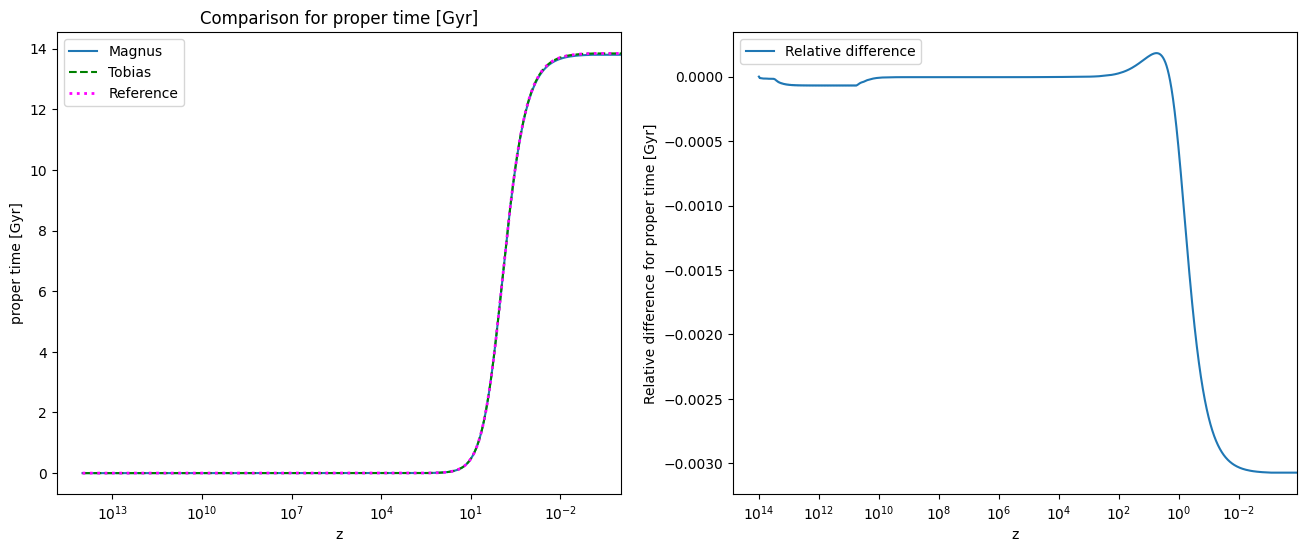

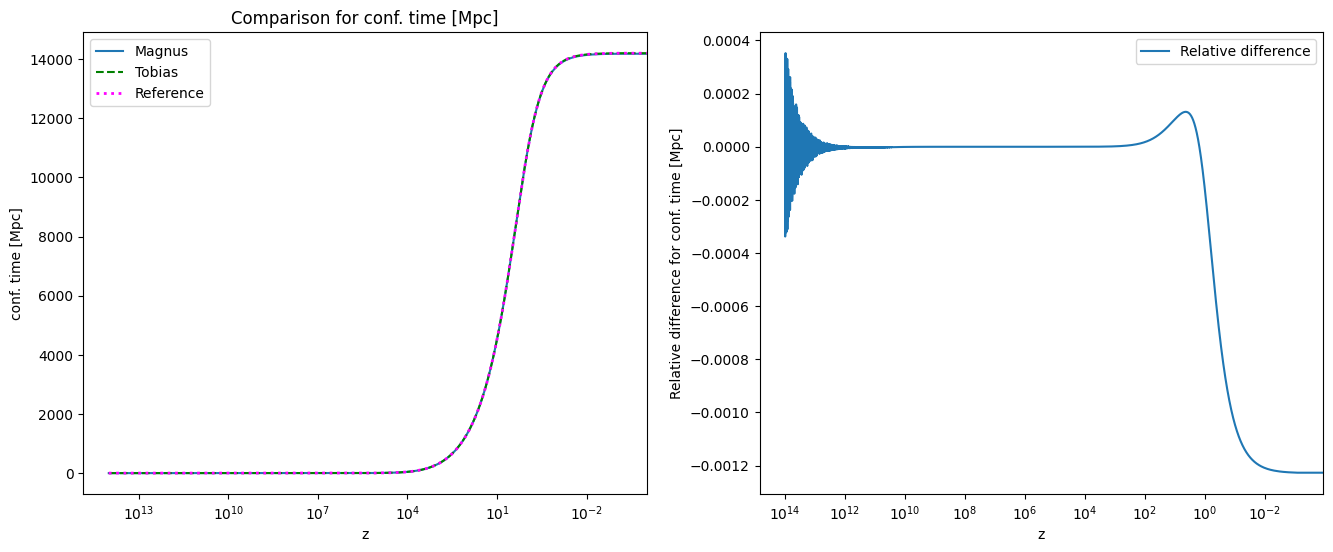

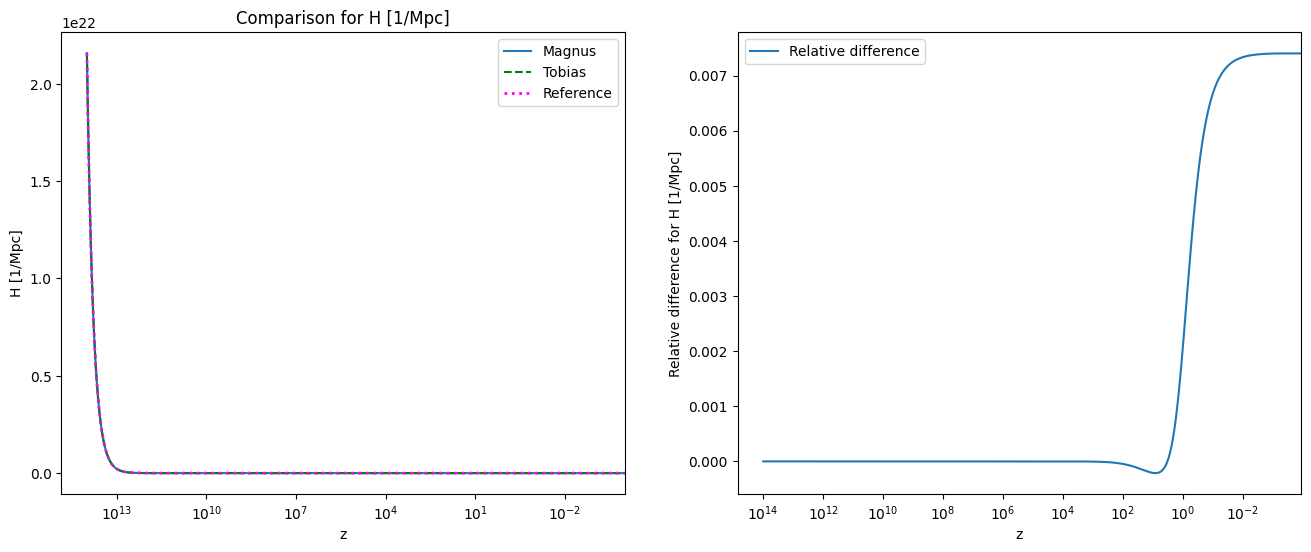

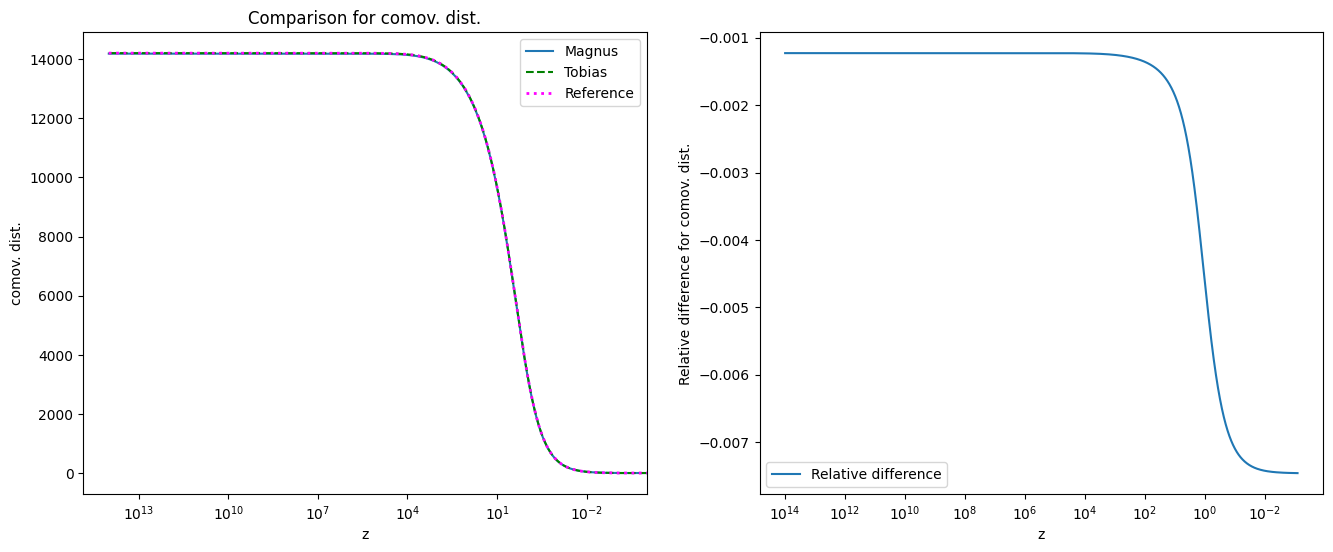

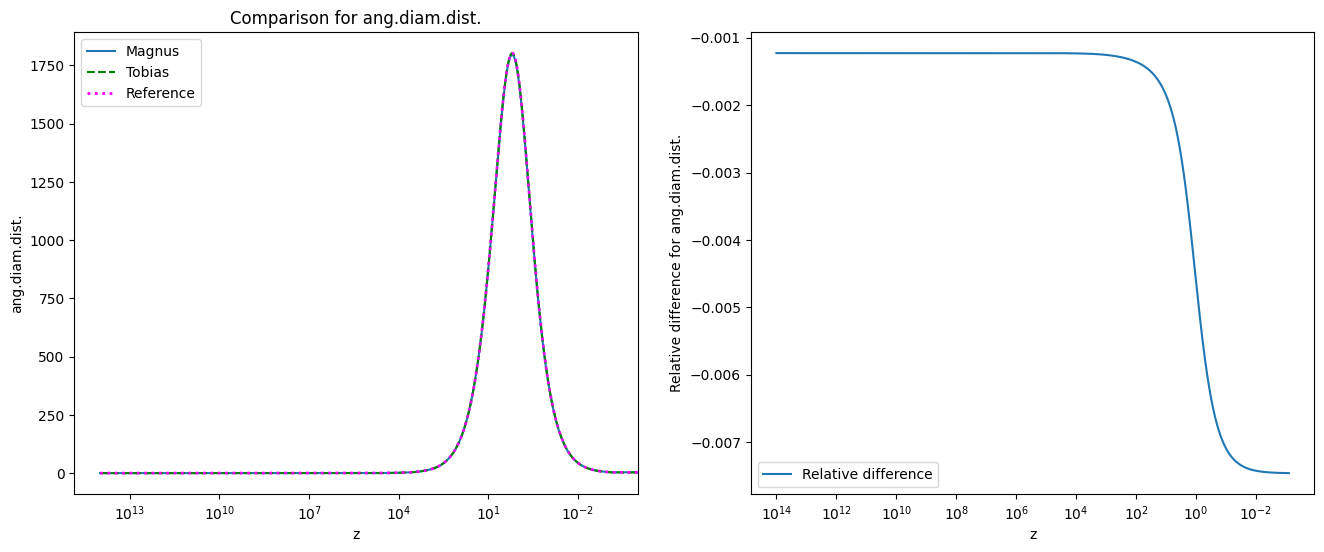

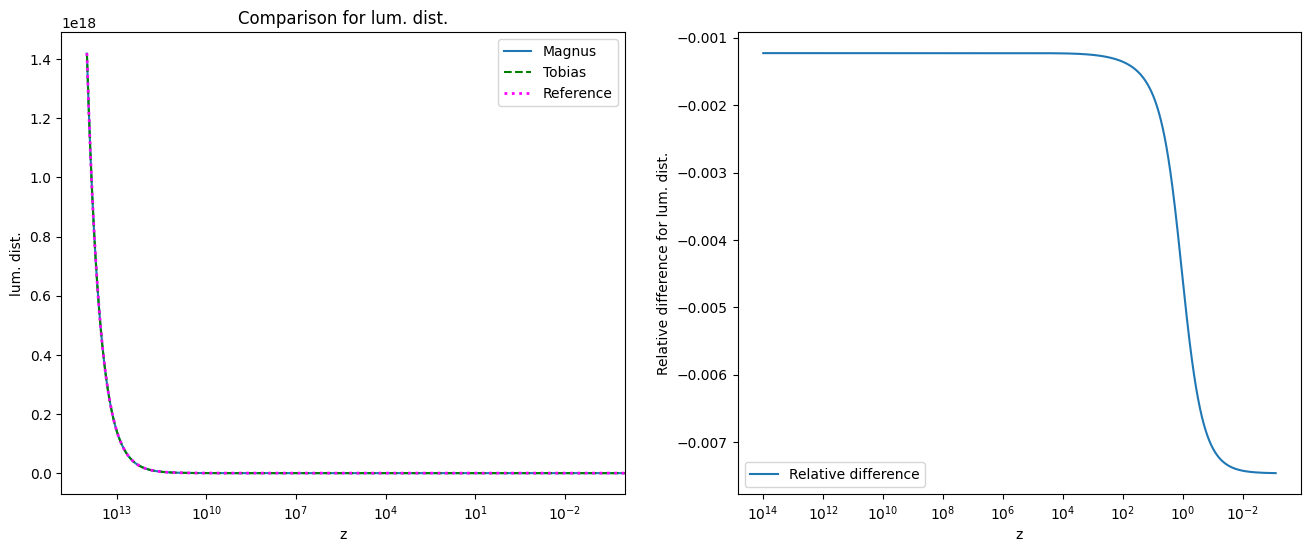

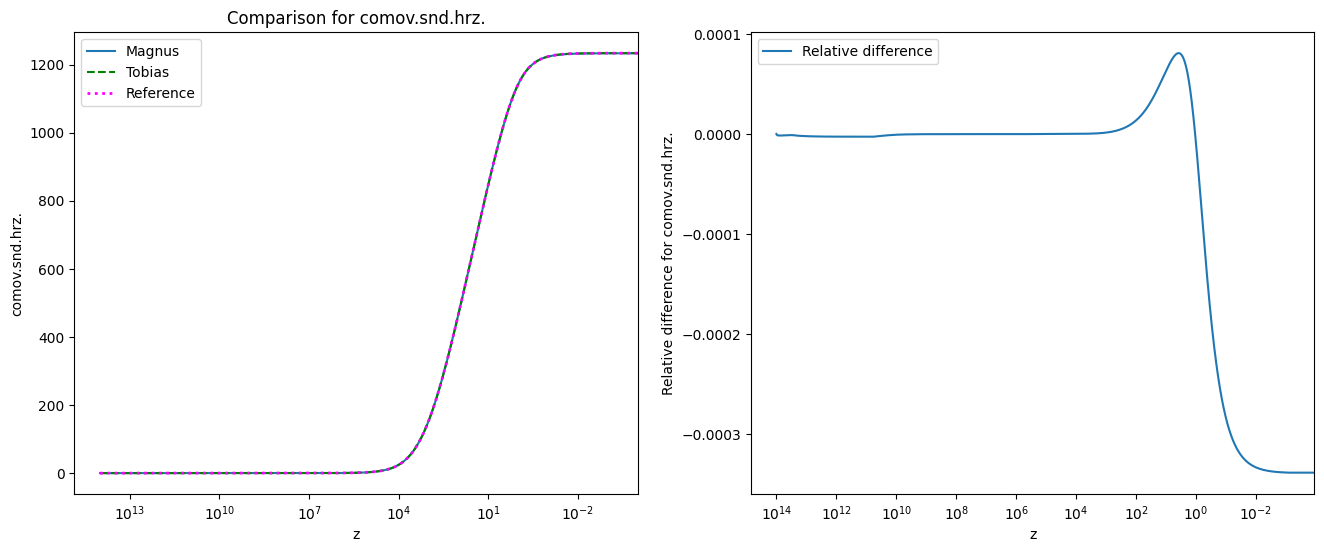

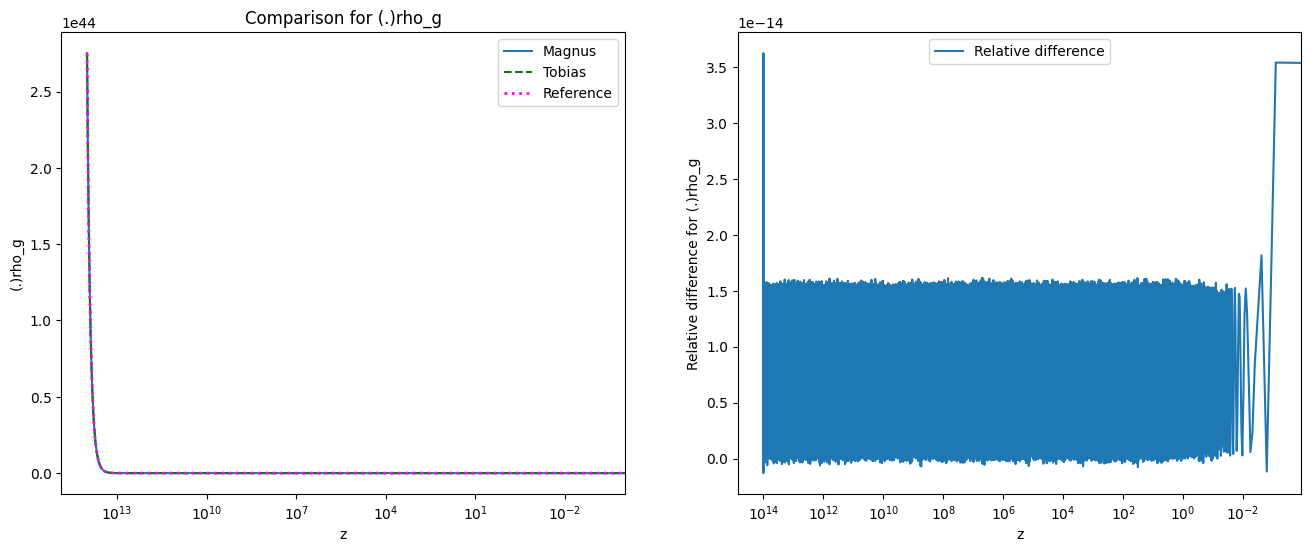

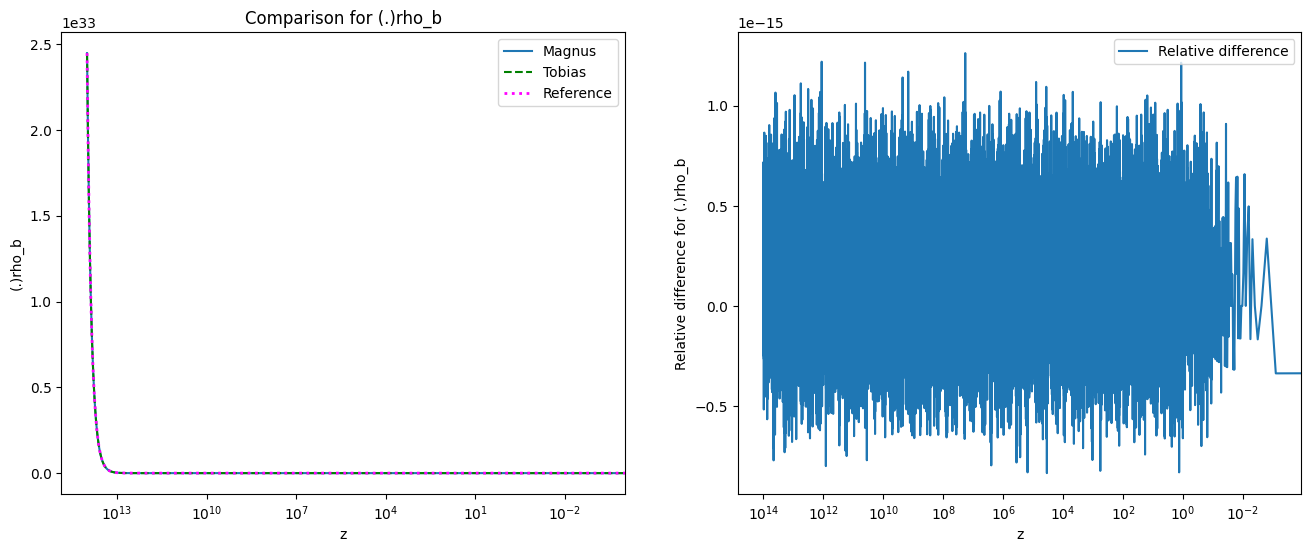

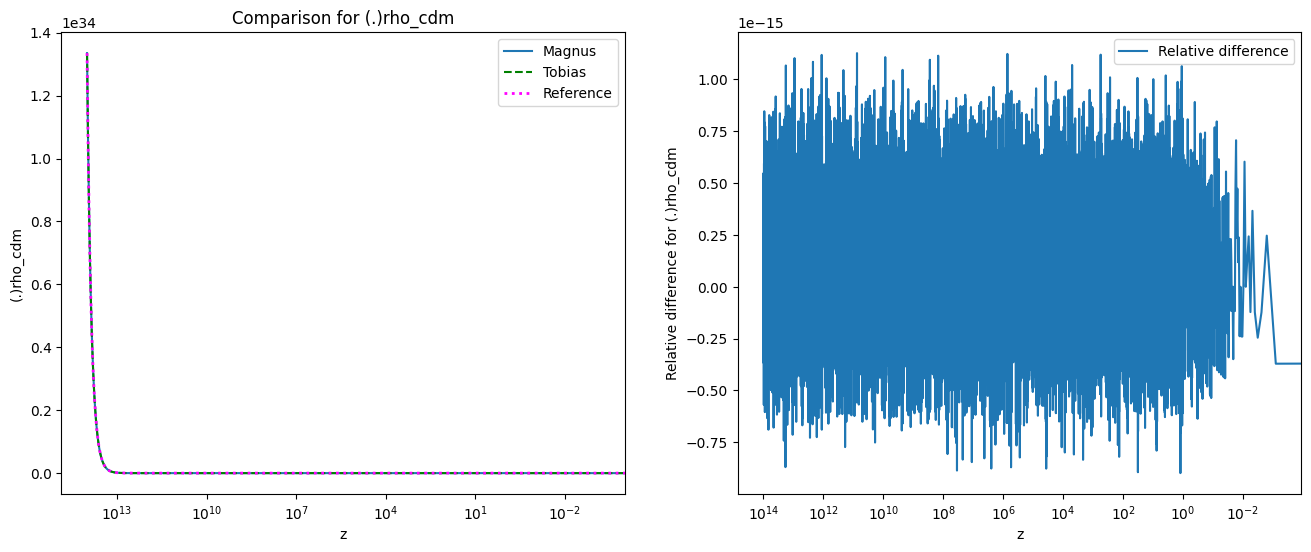

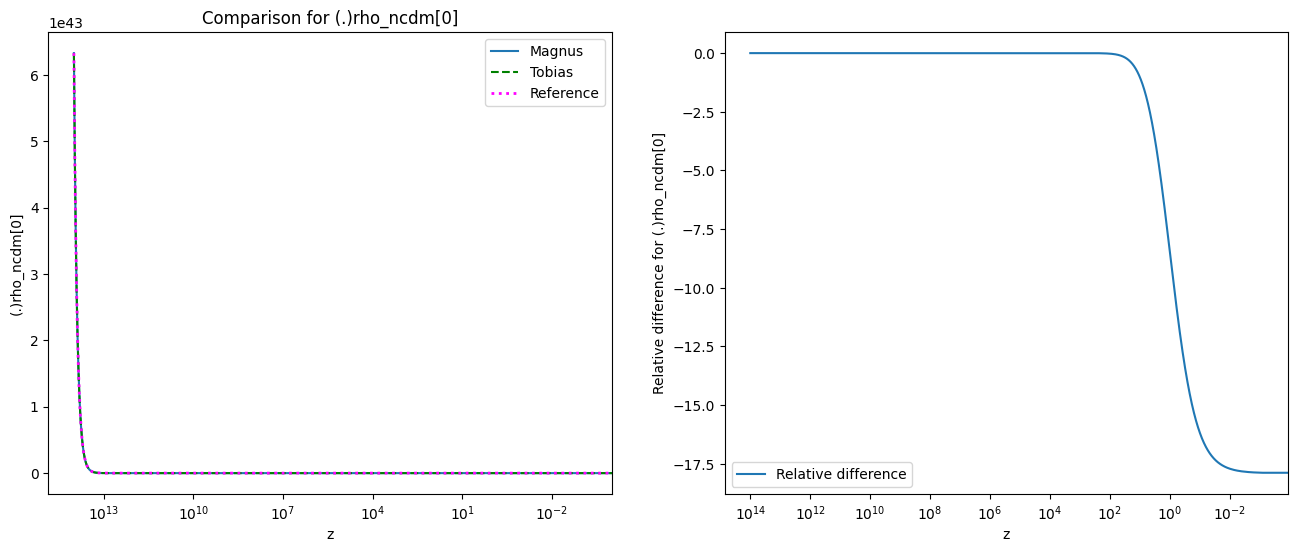

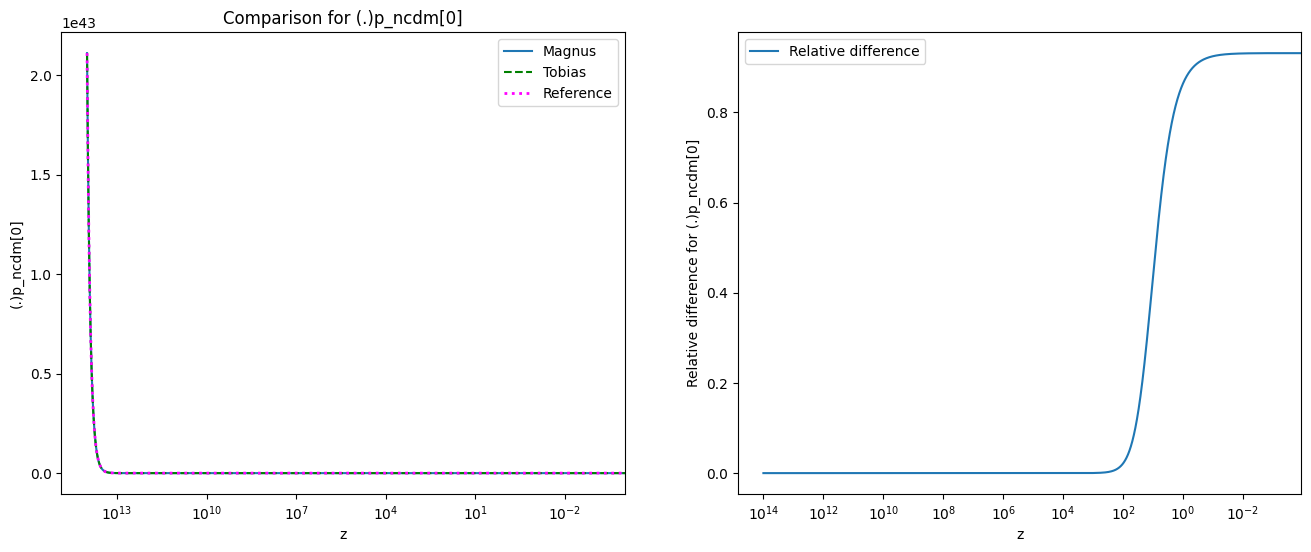

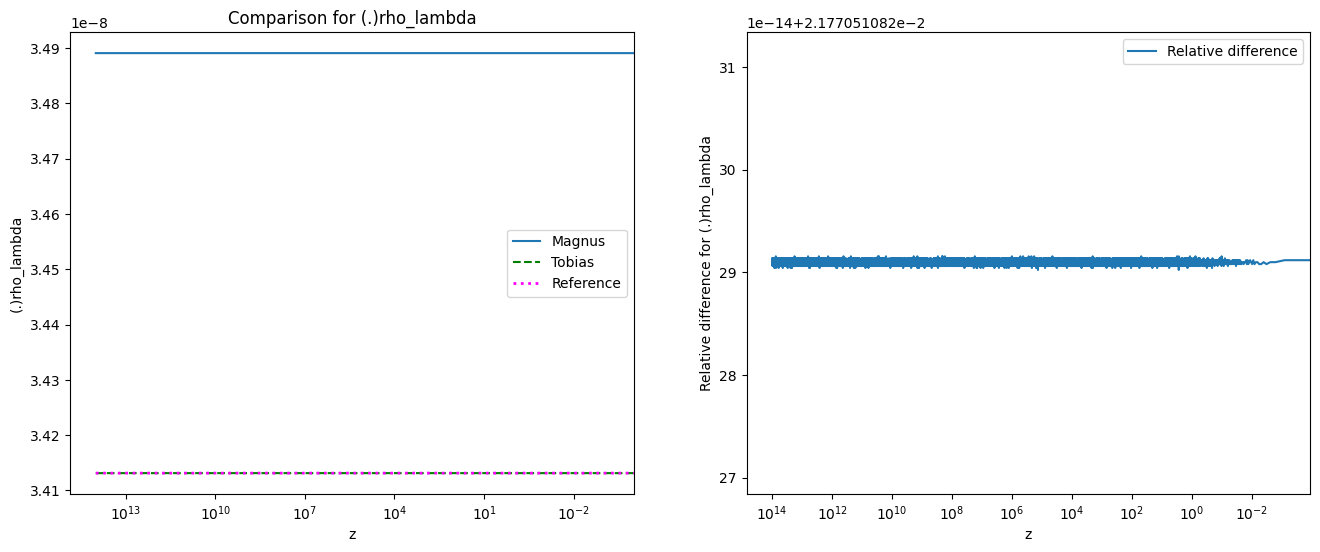

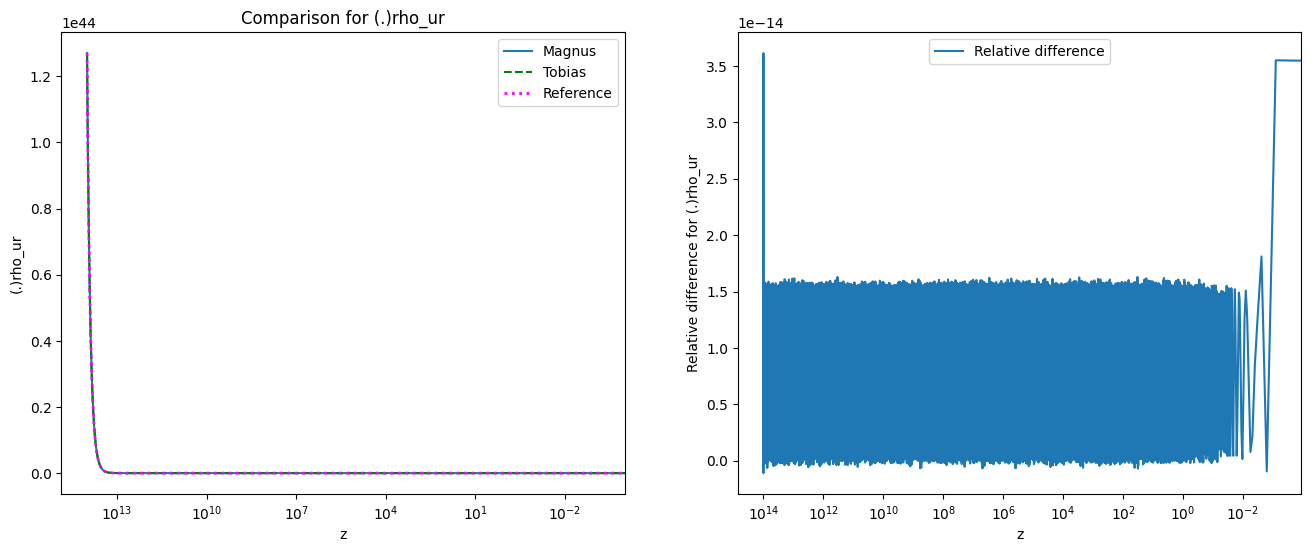

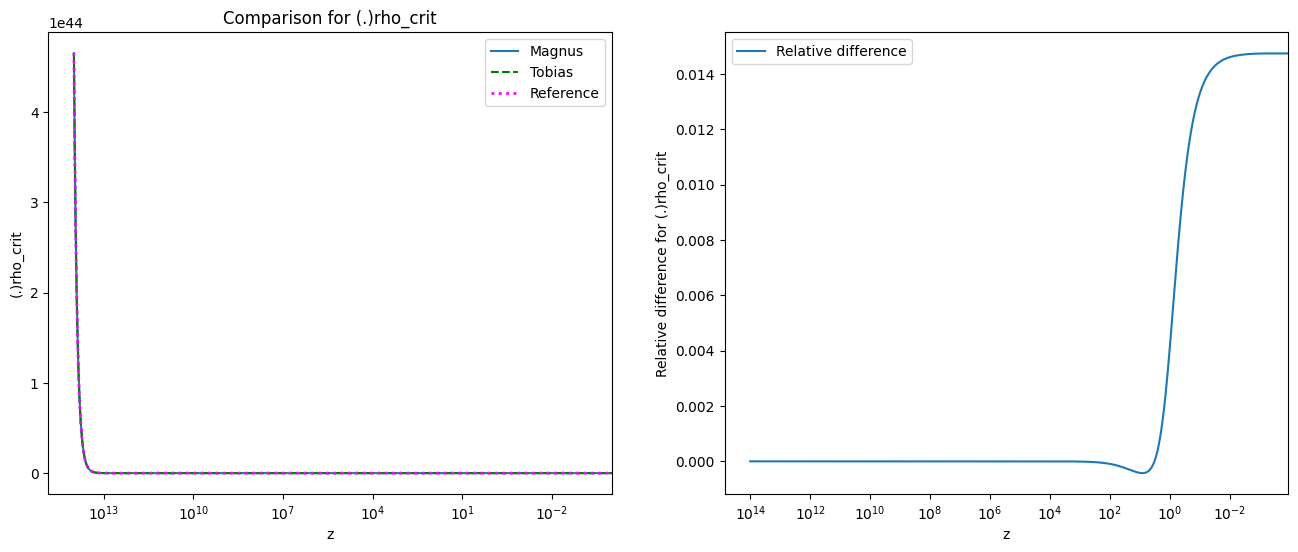

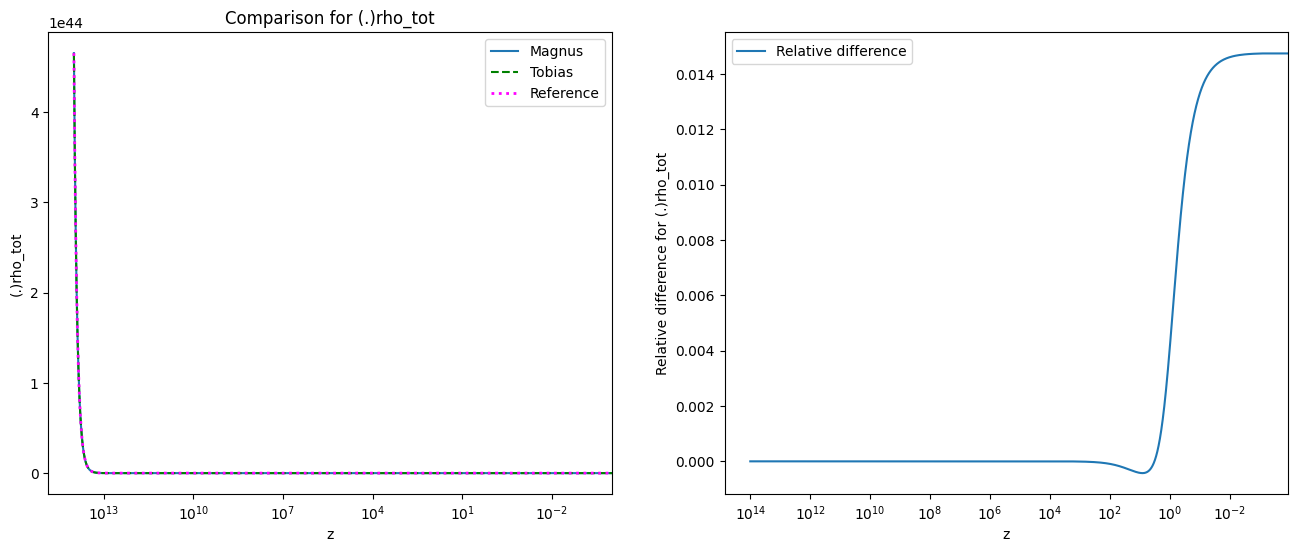

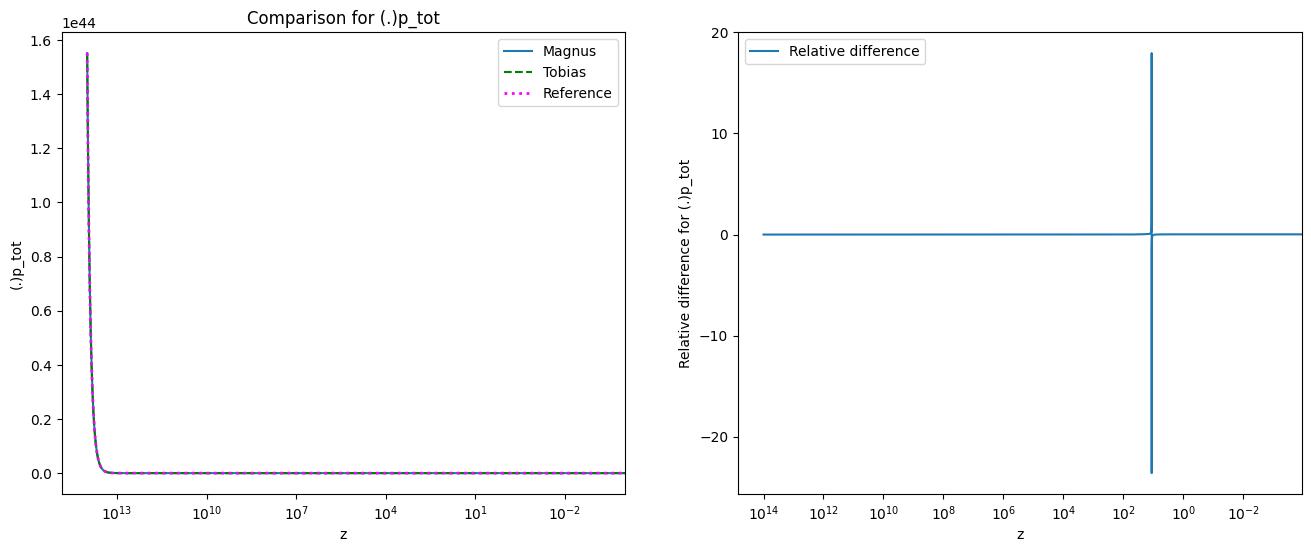

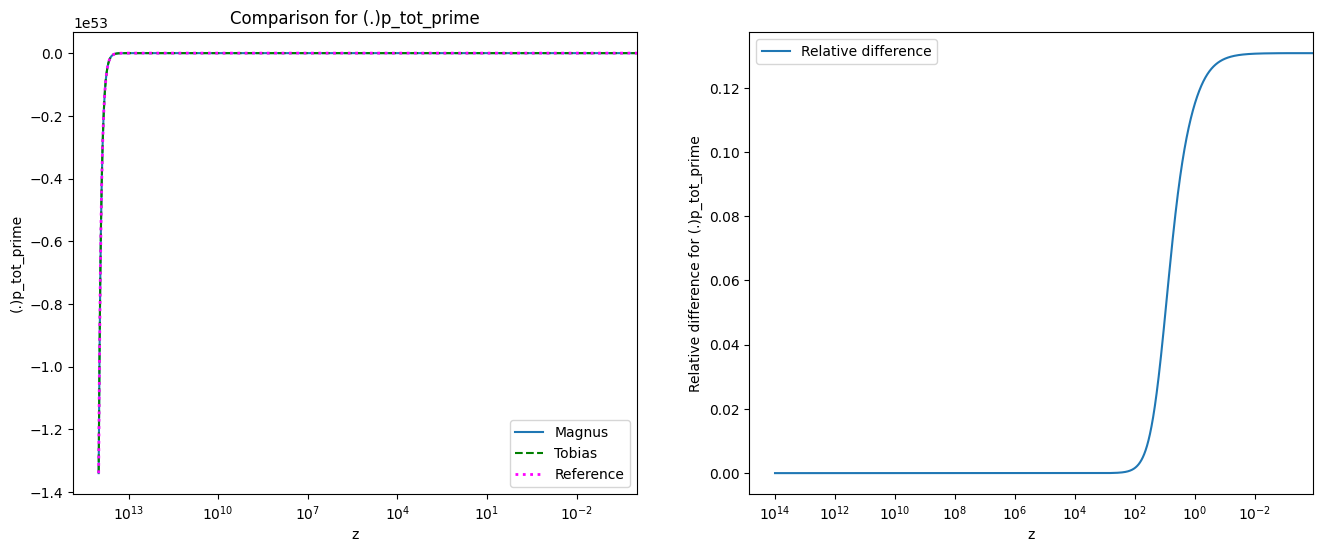

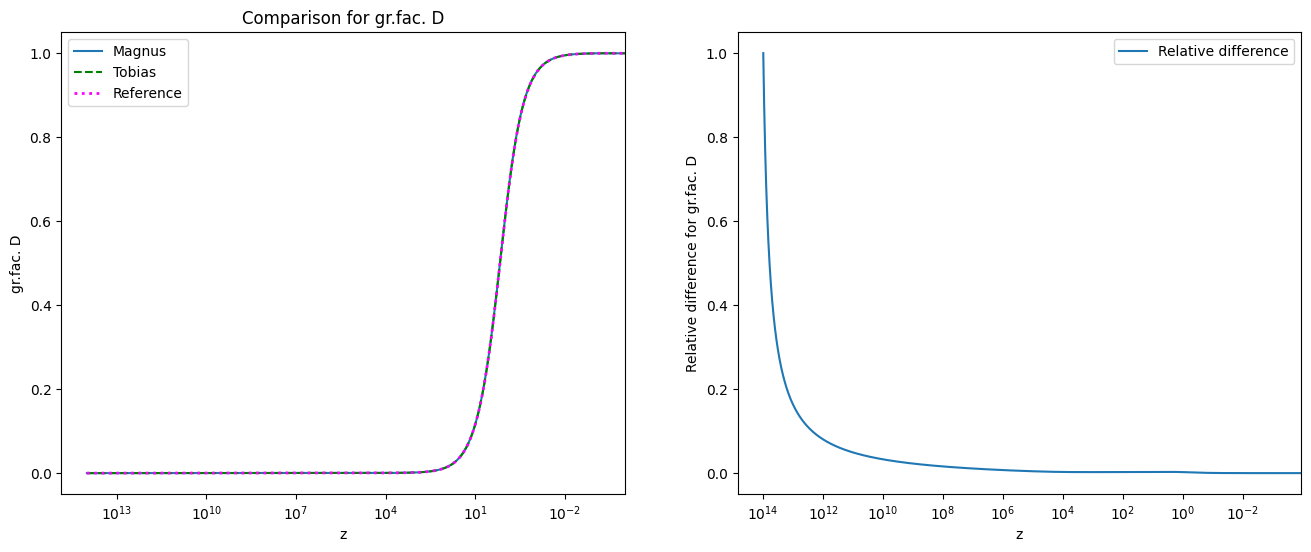

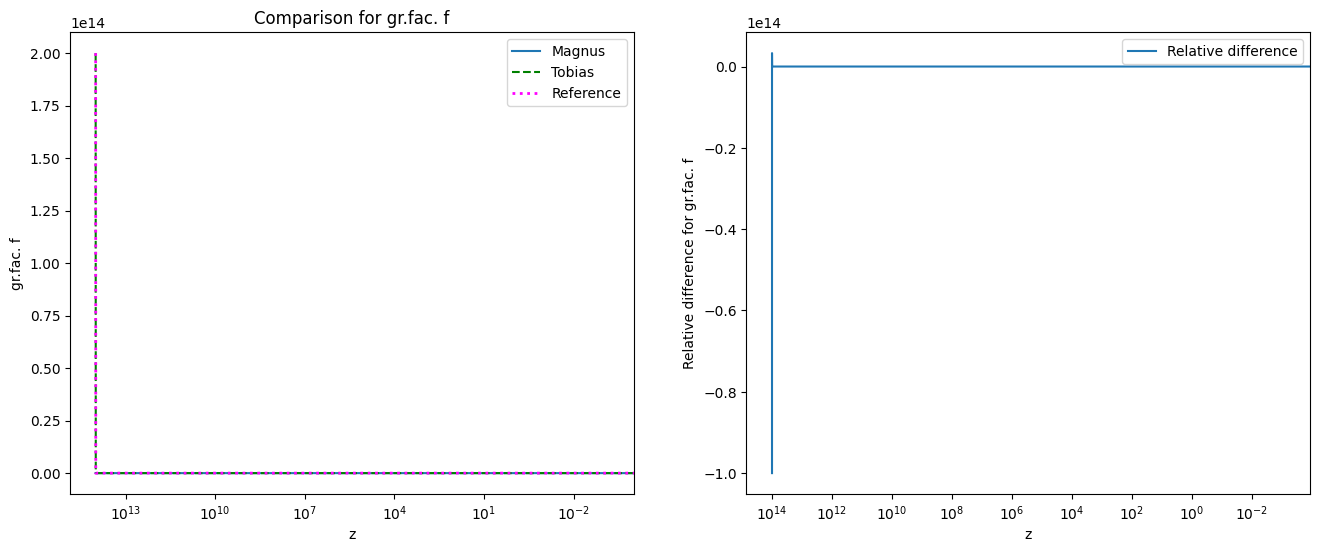

In [5]:
z_magnus = background_Magnus_ncdm['z']
z_tobias = background_Tobias_ncdm['z']
z_reference = background_reference_ncdm['z']


for key in background_Magnus_ncdm.keys():
    if key == 'z':
        continue
    

    fig, axs = plt.subplots(1,2,figsize=(16,6))
    
    axs[0].plot(z_magnus, background_Magnus_ncdm[key], label='Magnus', ls='solid')
    axs[0].plot(z_tobias, background_Tobias_ncdm[key], label='Tobias', ls='dashed', color = 'green')
    axs[0].plot(z_reference, background_reference_ncdm[key], label='Reference', ls='dotted', lw =2, color = 'magenta')
    axs[0].set(xlabel='z', ylabel=key, xscale='log')
    axs[0].invert_xaxis()  # Invert x-axis to have z decreasing from left to right
    axs[0].set_title(f'Comparison for {key}')
    axs[0].legend()


    #Create a logscale plot of the relative difference between Magnus and Tobias. First, we need to interpolate the Tobias data to the same z values as Magnus.
    interp_Tobias = interp1d(z_tobias, background_Tobias_ncdm[key], kind='cubic', fill_value='extrapolate')
    Tobias_interp = interp_Tobias(z_magnus)

    relative_difference = (background_Magnus_ncdm[key] - Tobias_interp) / background_Magnus_ncdm[key]
    axs[1].plot(z_magnus, relative_difference, label='Relative difference', ls='solid')
    axs[1].set(xlabel='z', ylabel=f'Relative difference for {key}', xscale='log')
    axs[1].invert_xaxis()  # Invert x-axis to have z decreasing from left to right
    axs[1].legend()

scale factor a
z
conf. time [Mpc]
x_e
kappa' [Mpc^-1]
exp(-kappa)
g [Mpc^-1]
Tb [K]
dTb [K]
w_b
c_b^2
tau_d


/tmp/ipykernel_14962/841844191.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  ratio_Magnus = np.max(val_Magnus) / np.min(val_Magnus)
/tmp/ipykernel_14962/841844191.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  ratio_Tobias = np.max(val_Tobias) / np.min(val_Tobias)
/tmp/ipykernel_14962/841844191.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  ratio_reference = np.max(val_reference) / np.min(val_reference)
/tmp/ipykernel_14962/841844191.py:40: RuntimeWarning: divide by zero encountered in divide
  relative_difference = (thermodynamics_Magnus_ncdm[key] - Tobias_interp) / thermodynamics_Magnus_ncdm[key]
/tmp/ipykernel_14962/841844191.py:40: RuntimeWarning: invalid value encountered in divide
  relative_difference = (thermodynamics_Magnus_ncdm[key] - Tobias_interp) / thermodynamics_Magnus_ncdm[key]
/tmp/ipykernel_14962/841844191.py:21: RuntimeWarning: overflow encountered in scalar divide
  ratio_Magnus = np.max(val_Magnus) /

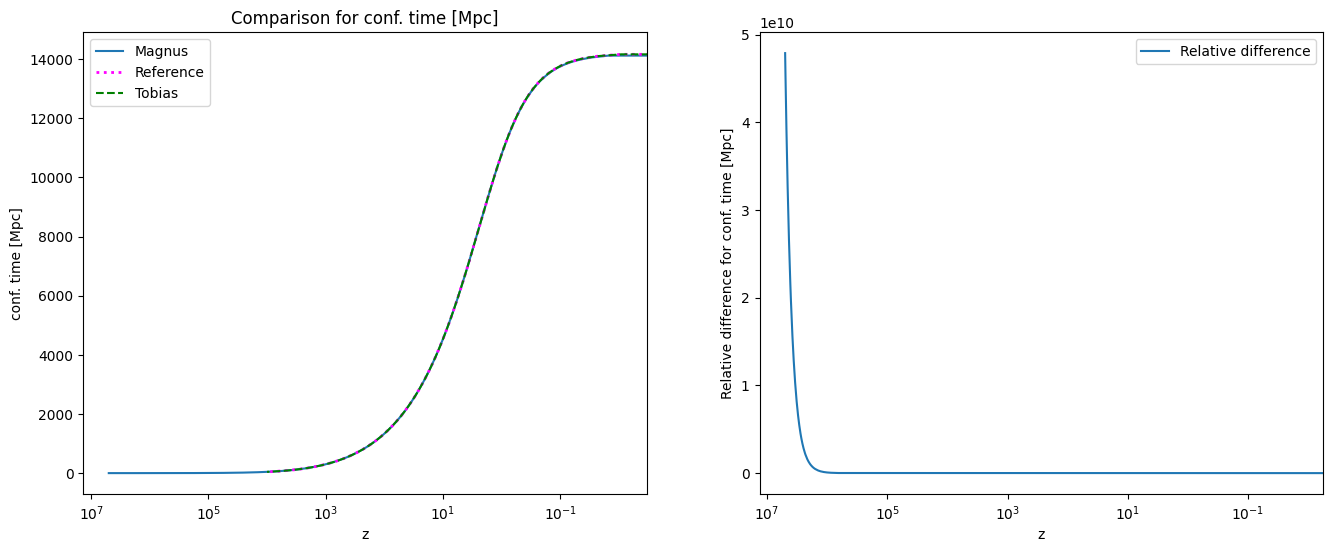

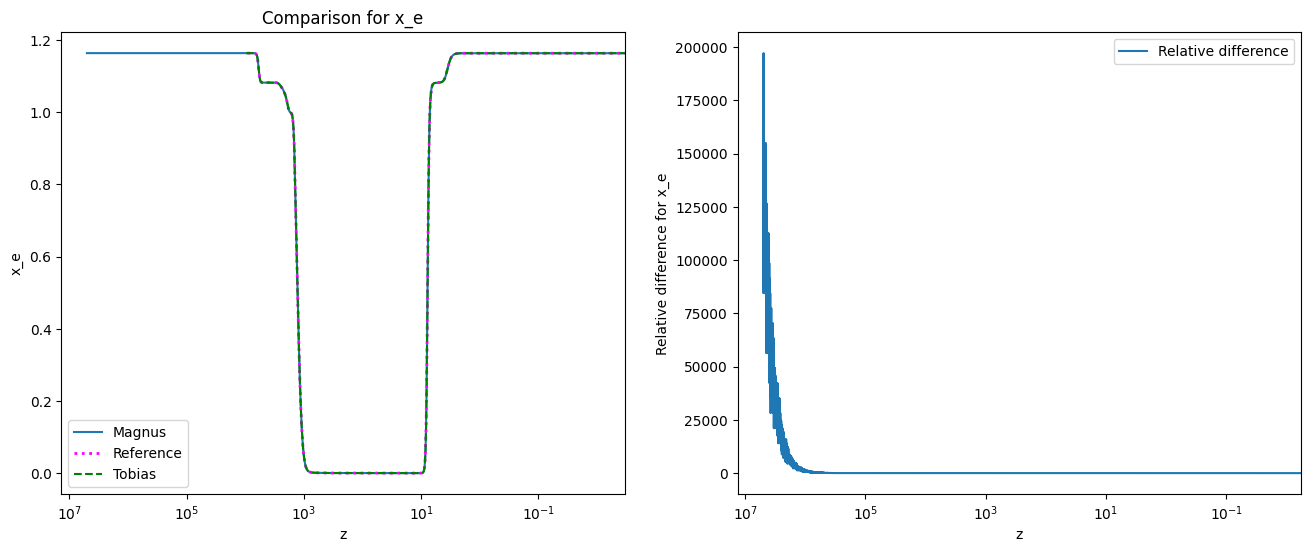

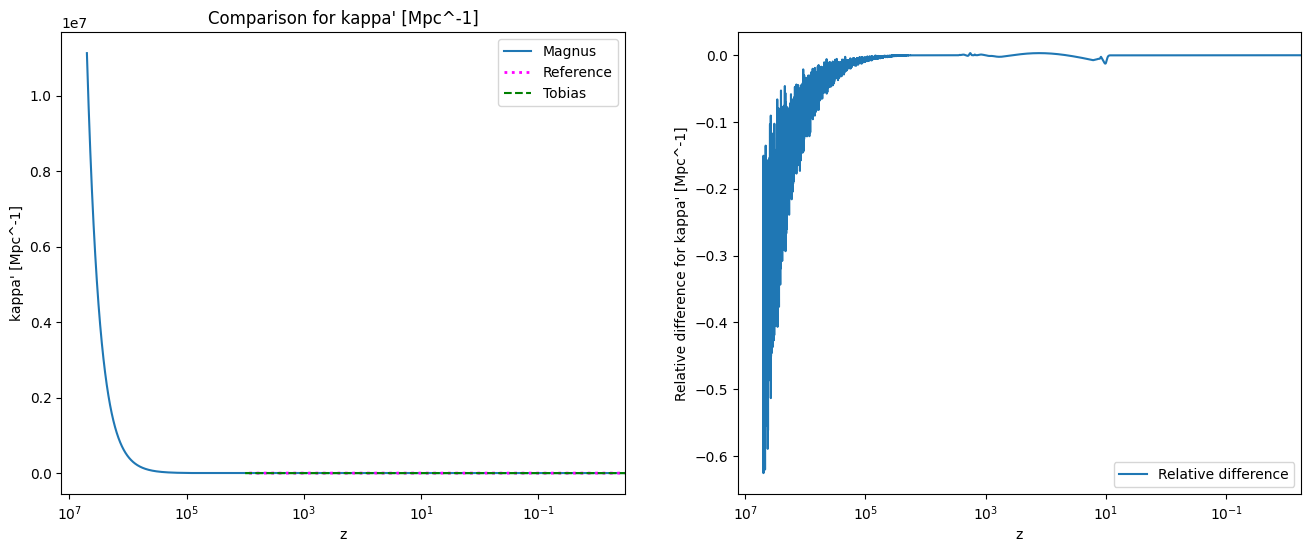

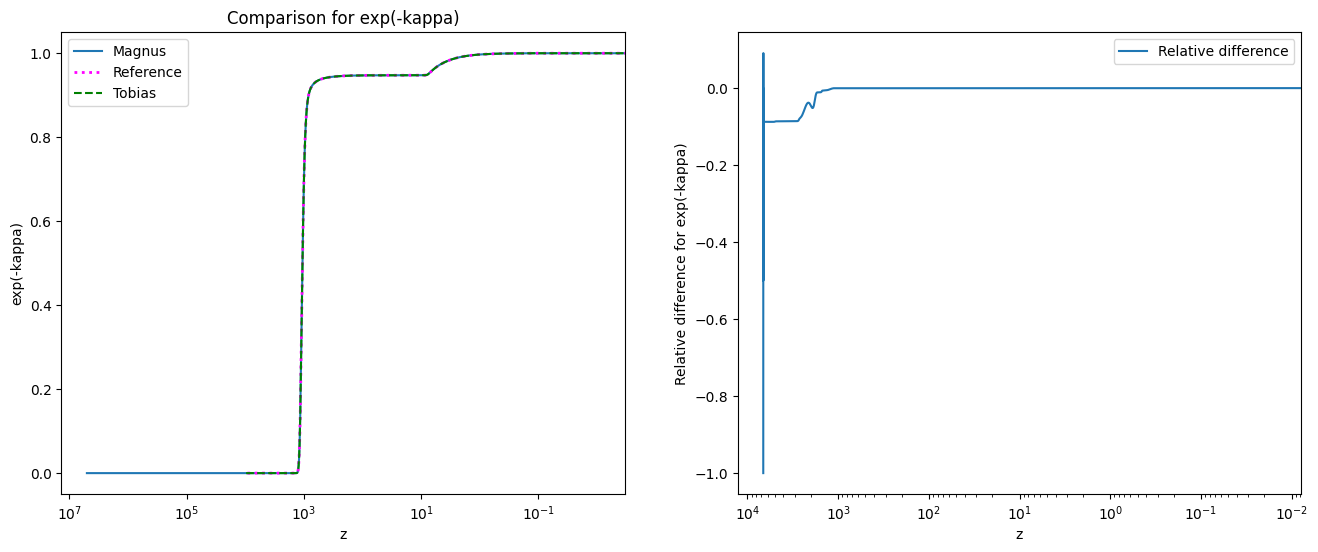

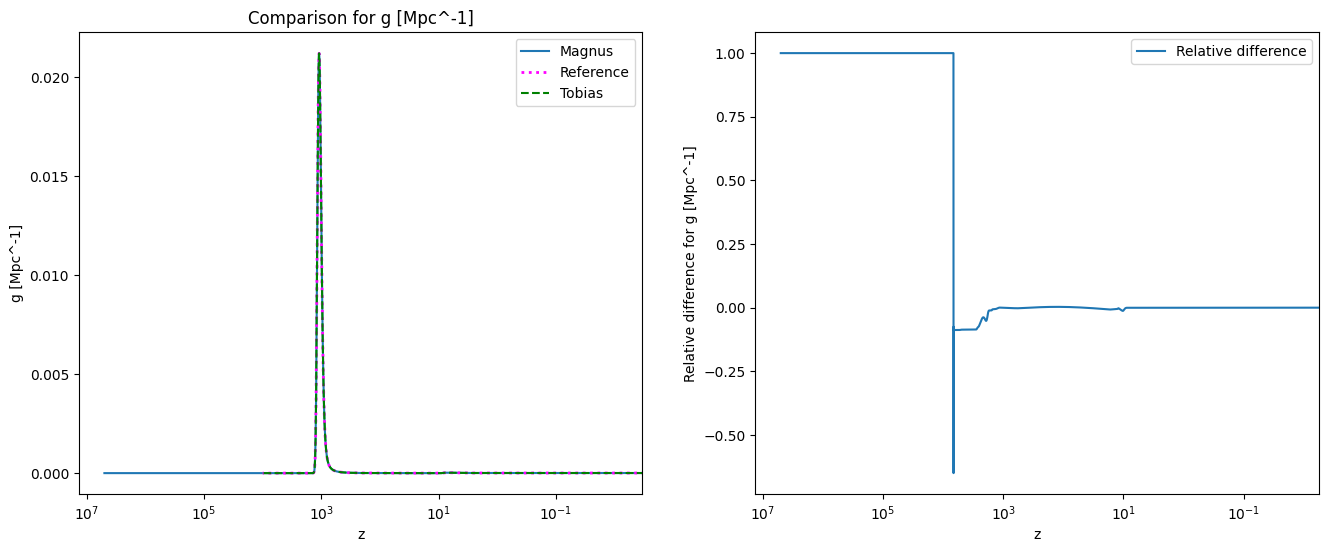

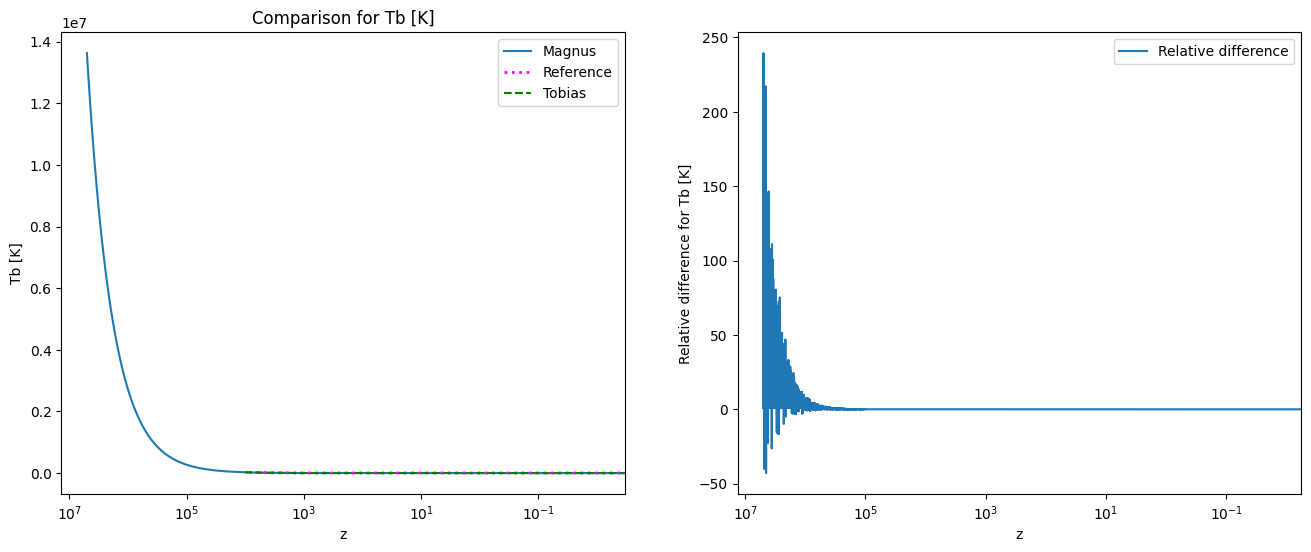

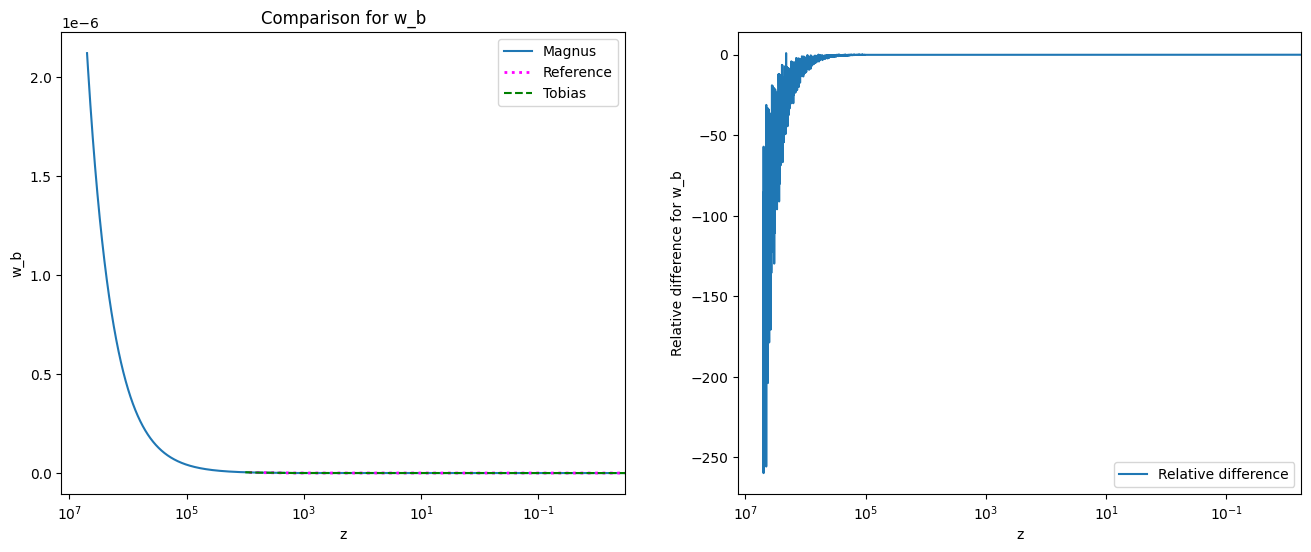

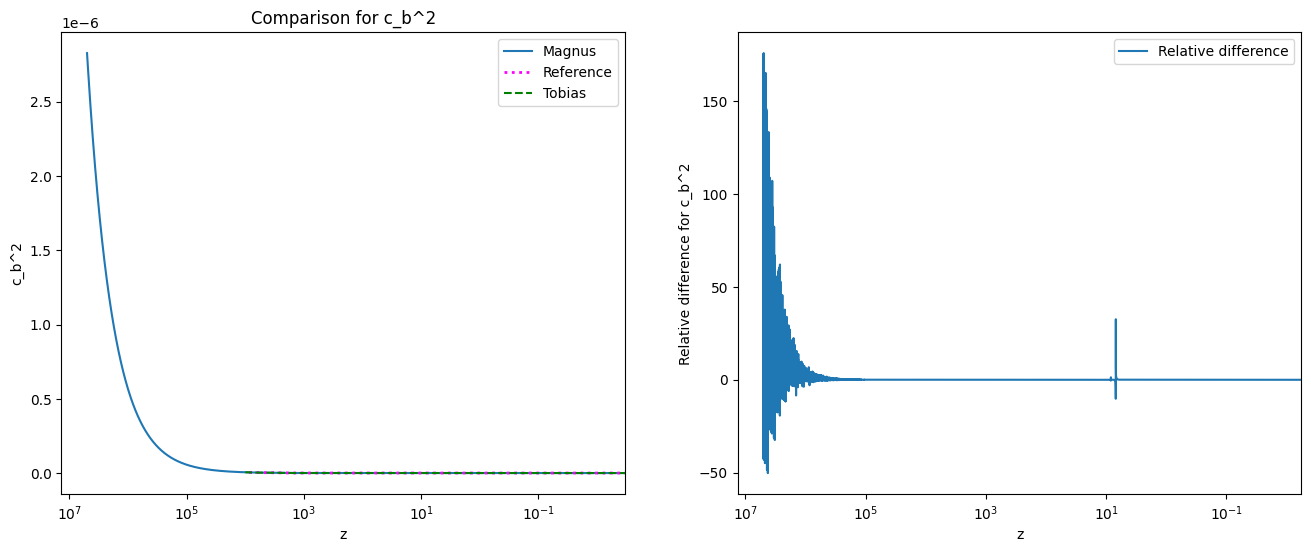

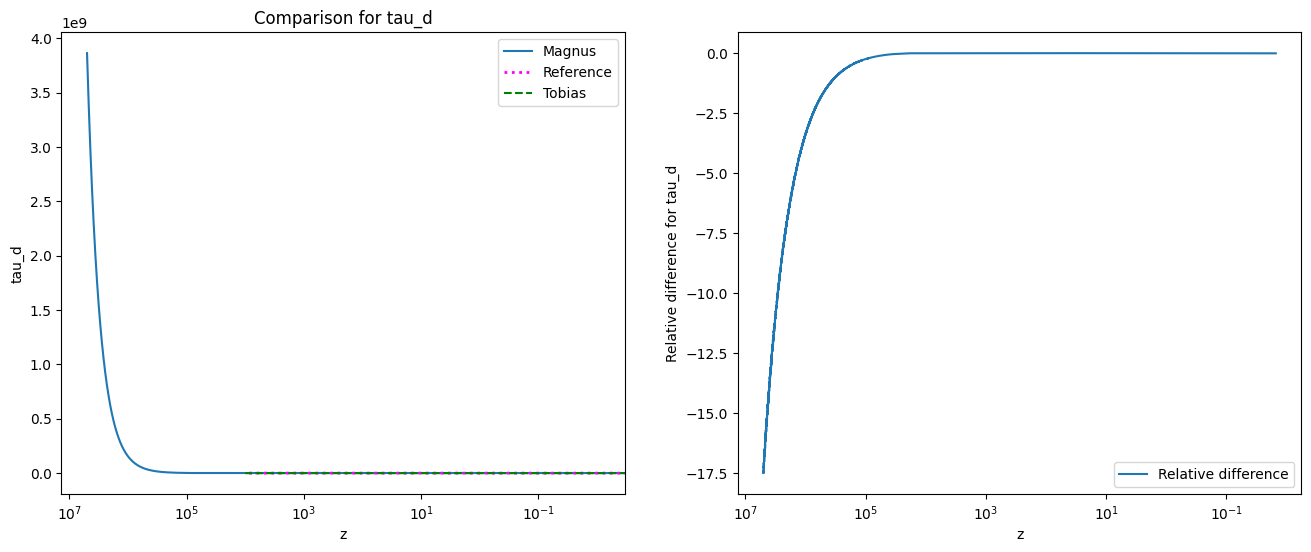

In [6]:
thermodynamics_Magnus_ncdm = model_Magnus_ncdm.get_thermodynamics()
thermodynamics_Tobias_ncdm = model_Tobias_ncdm.get_thermodynamics()
thermodynamics_reference_ncdm = model_reference_ncdm.get_thermodynamics()

for key in thermodynamics_Magnus_ncdm.keys():
    print(key)
z_Magnus = thermodynamics_Magnus_ncdm['z']
z_reference = thermodynamics_reference_ncdm['z']
z_Tobias = thermodynamics_Tobias_ncdm['z']

for key in thermodynamics_Tobias_ncdm.keys():
    if key == 'z' or key == 'scale factor a':
        continue
    fig, axs = plt.subplots(1,2,figsize=(16,6))

    val_Magnus = thermodynamics_Magnus_ncdm[key]
    val_Tobias = thermodynamics_Tobias_ncdm[key]
    val_reference = thermodynamics_reference_ncdm[key]

    #If the order of magnitude of the values is very different, we can plot them on a log scale. We can check this by looking at the ratio of the maximum to minimum value for each dataset. If the ratio is greater than 100, we can plot on a log scale.
    ratio_Magnus = np.max(val_Magnus) / np.min(val_Magnus)
    ratio_Tobias = np.max(val_Tobias) / np.min(val_Tobias)
    ratio_reference = np.max(val_reference) / np.min(val_reference)




    axs[0].plot(z_Magnus, thermodynamics_Magnus_ncdm[key], label='Magnus', ls='solid')
    axs[0].plot(z_reference, thermodynamics_reference_ncdm[key], label='Reference', ls='dotted', lw =2, color = 'magenta')
    axs[0].plot(z_Tobias, thermodynamics_Tobias_ncdm[key], label='Tobias', ls='dashed', color = 'green')
    axs[0].set(xlabel='z', ylabel=key, xscale='log')
    axs[0].set_title(f'Comparison for {key}')
    axs[0].invert_xaxis()  # Invert x-axis to have z decreasing from left to right
    axs[0].legend()

    #Create a logscale plot of the relative difference between Magnus and Tobias. First, we need to interpolate the Tobias data to the same a values as Magnus.
    interp_Tobias = interp1d(z_Tobias, thermodynamics_Tobias_ncdm[key], kind='cubic', fill_value='extrapolate')
    Tobias_interp = interp_Tobias(z_Magnus)

    relative_difference = (thermodynamics_Magnus_ncdm[key] - Tobias_interp) / thermodynamics_Magnus_ncdm[key]
    axs[1].plot(z_Magnus, relative_difference, label='Relative difference', ls='solid')
    axs[1].set(xlabel='z', ylabel=f'Relative difference for {key}', xscale='log')
    axs[1].legend()
    axs[1].invert_xaxis()  # Invert x-axis to have z decreasing from left to right

DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=1  Nstd_in=0 Nint_in=1  => Nstd=0 Nint=1 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=0 Nint=1 Ntot=1  Geff_species=1.000e-03
dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_ncdm[0]', 'theta_ncdm[0]', 'shear_ncdm[0]', 'cs2_ncdm[0]'])


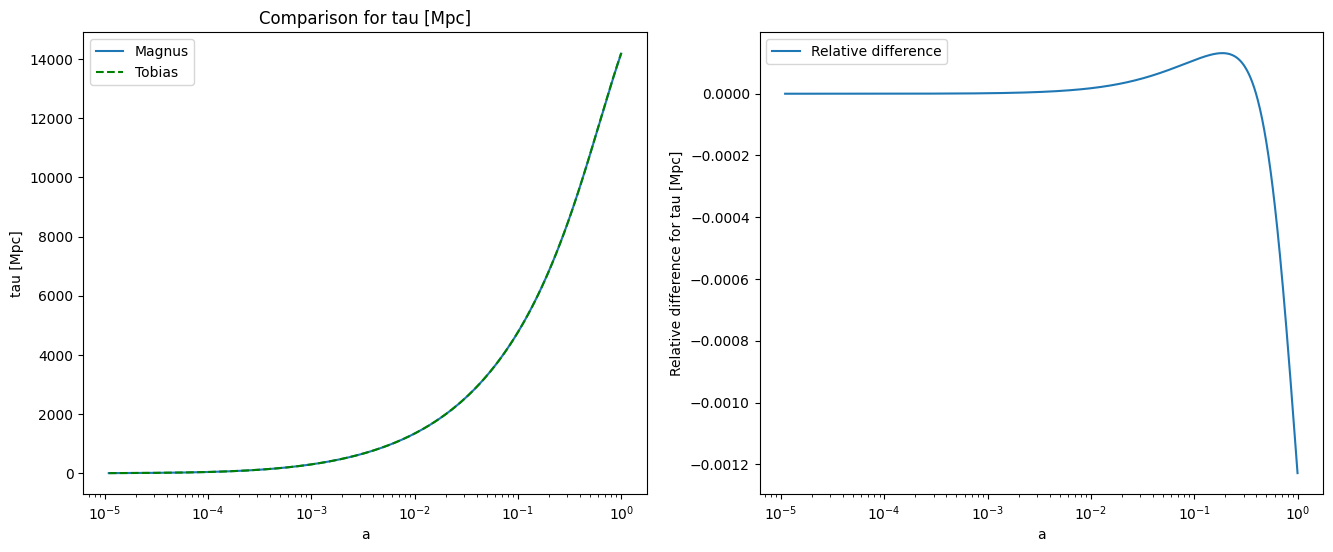

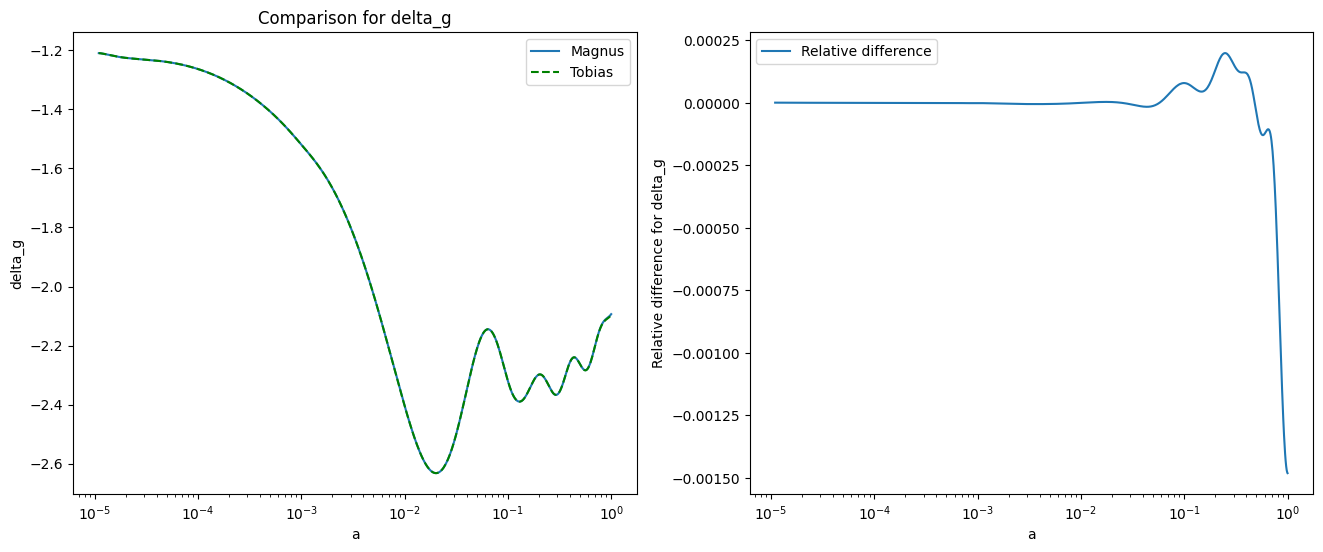

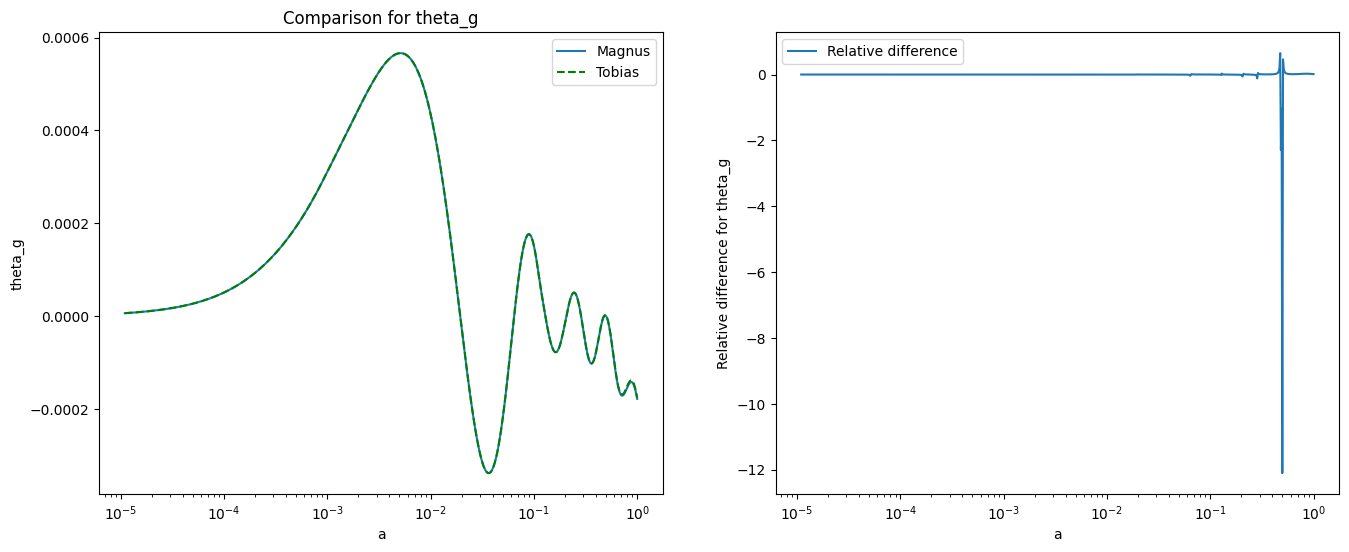

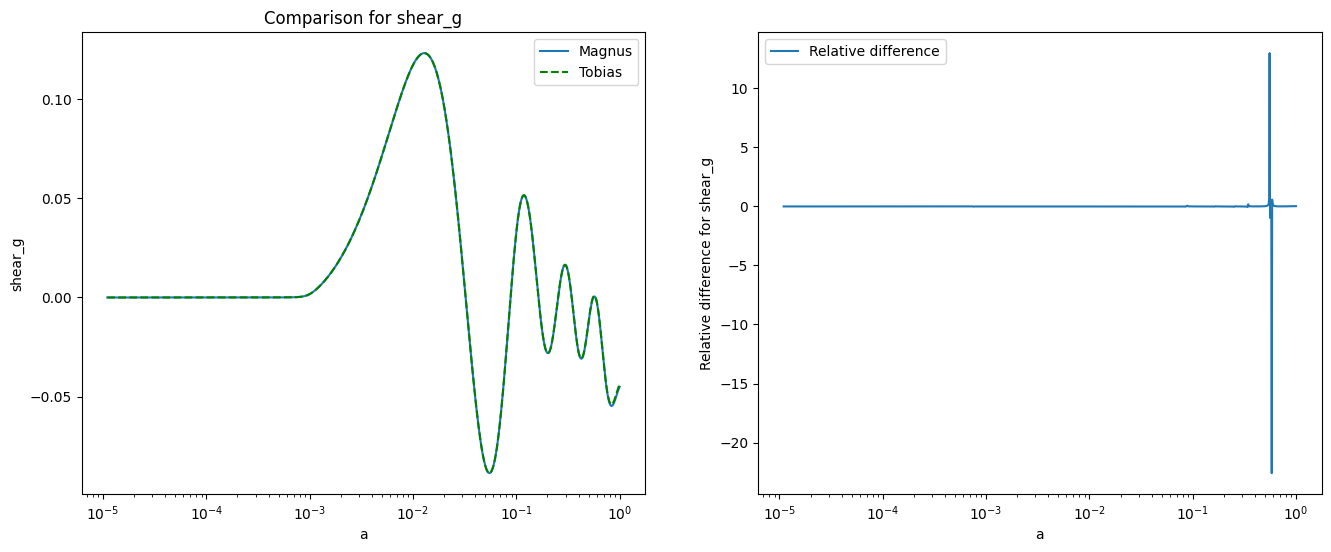

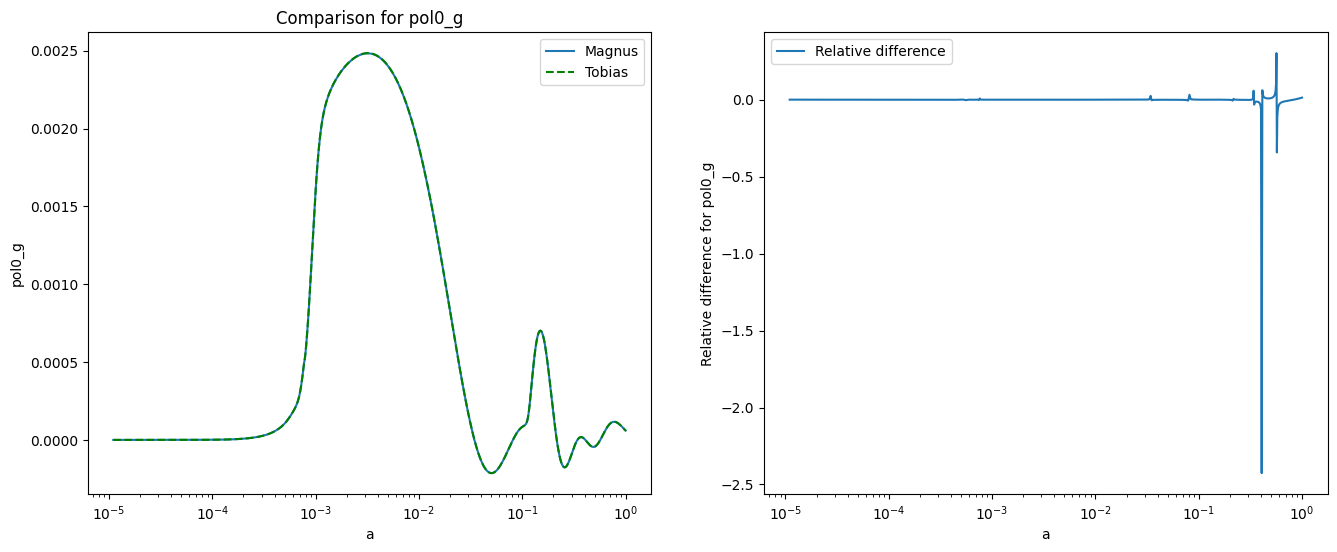

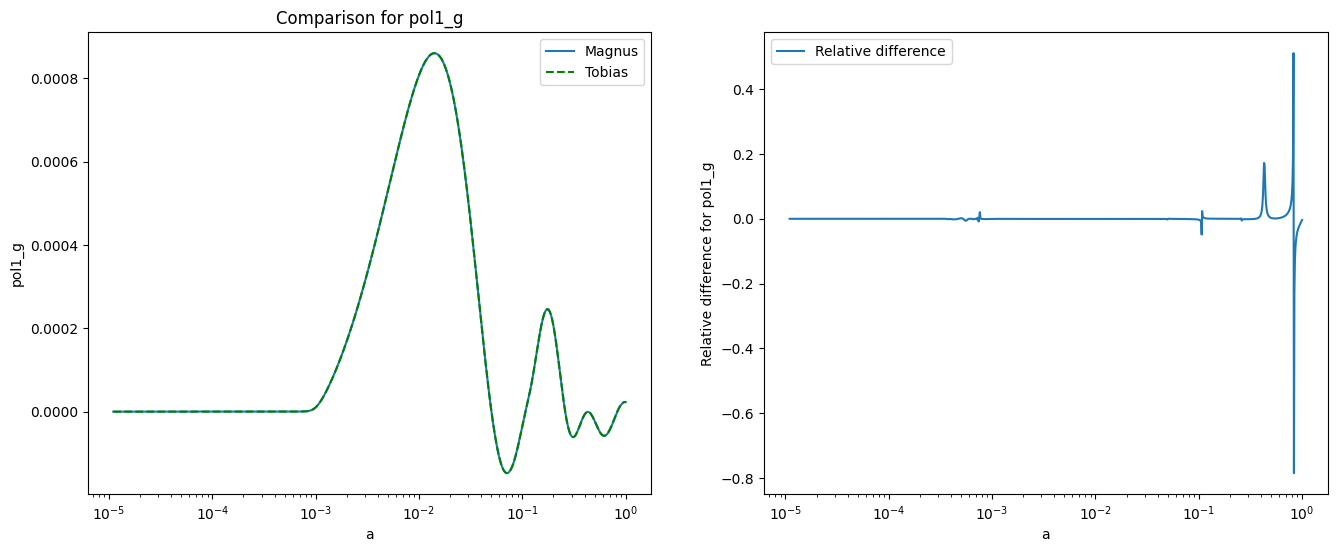

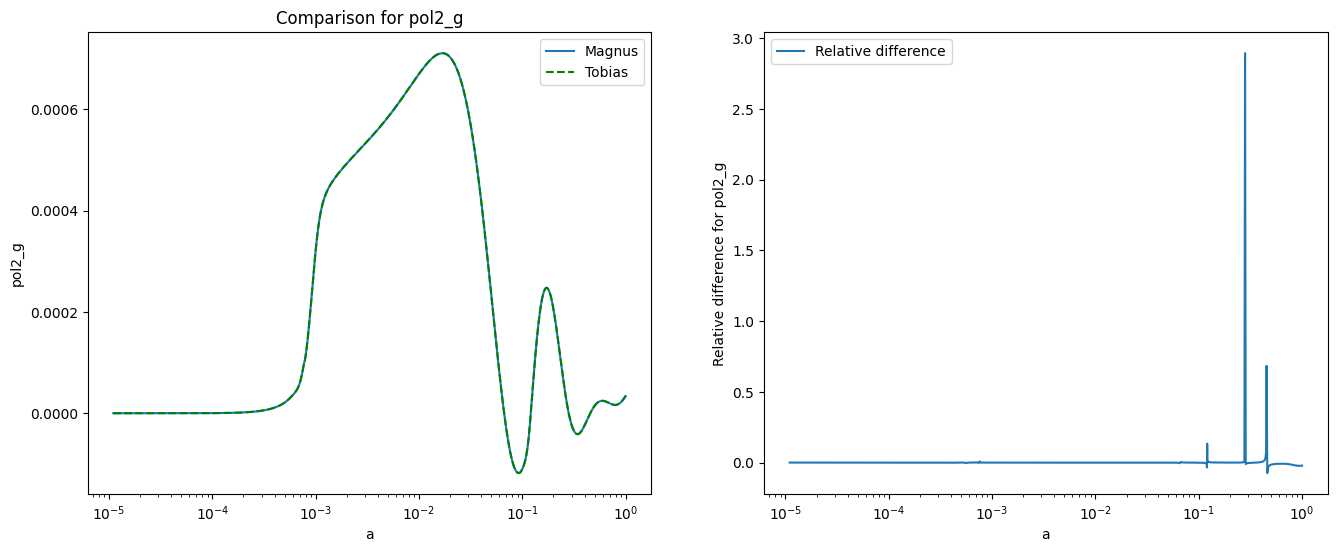

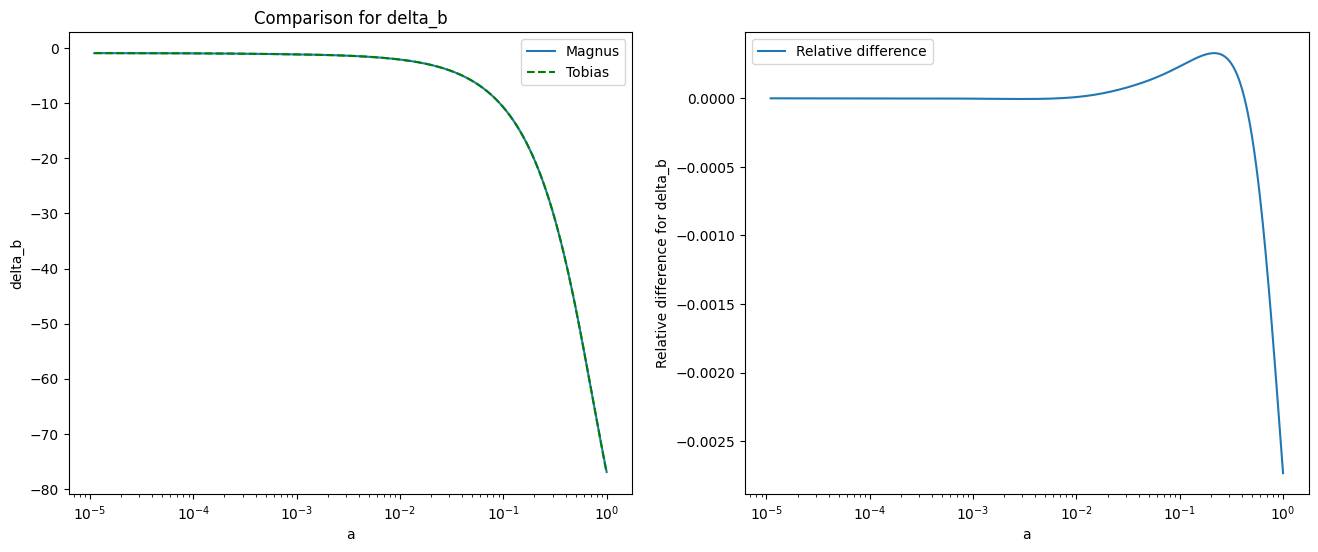

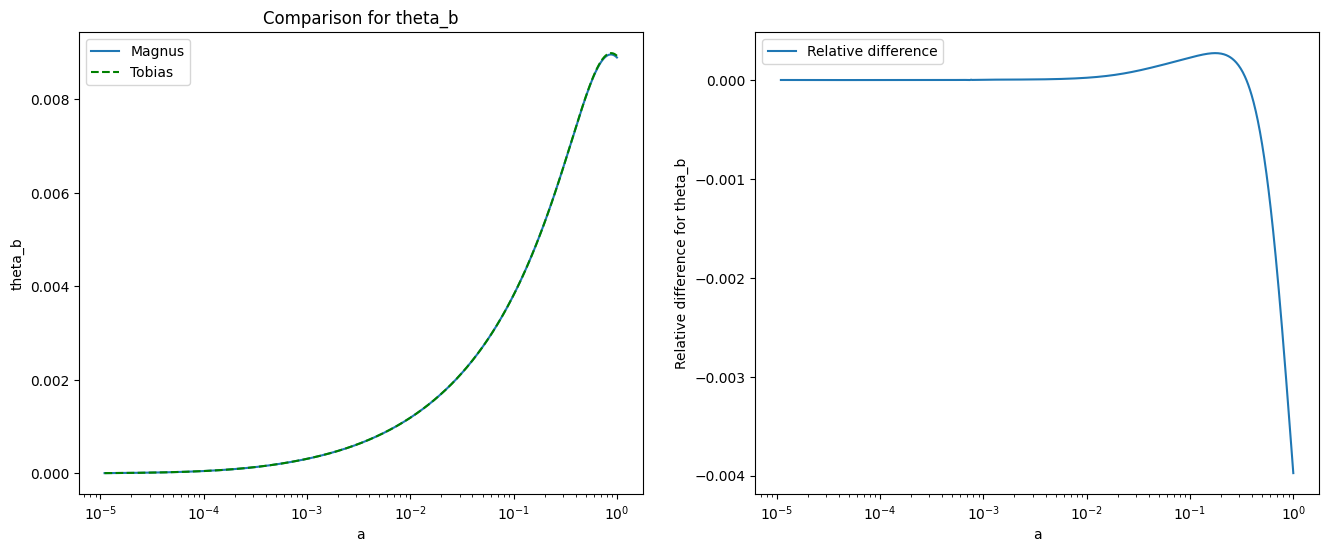

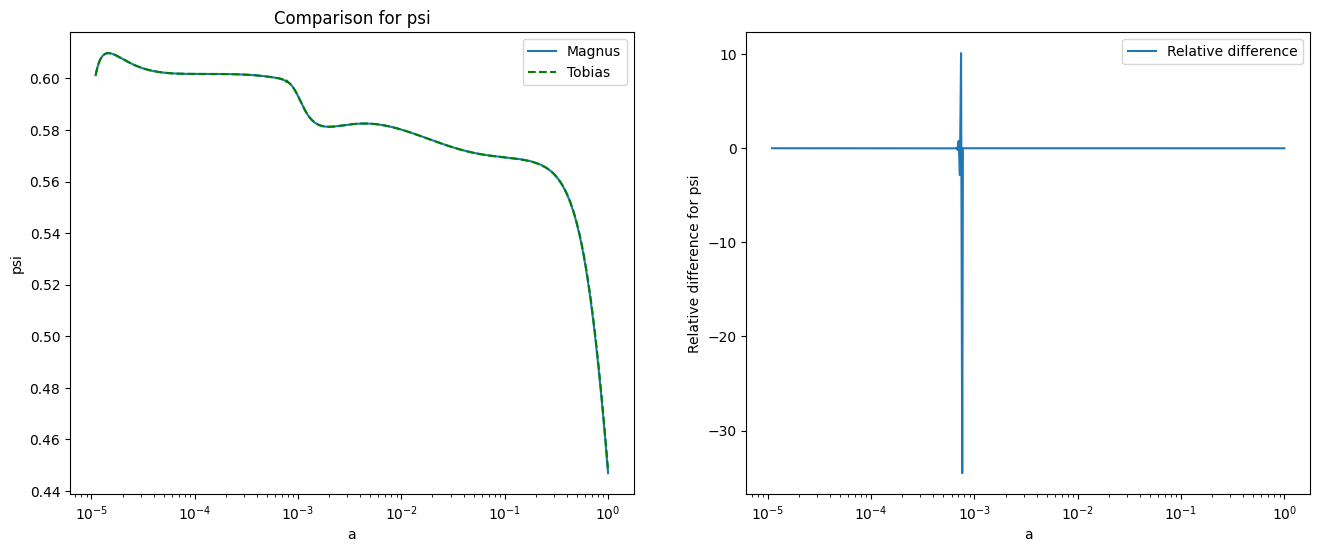

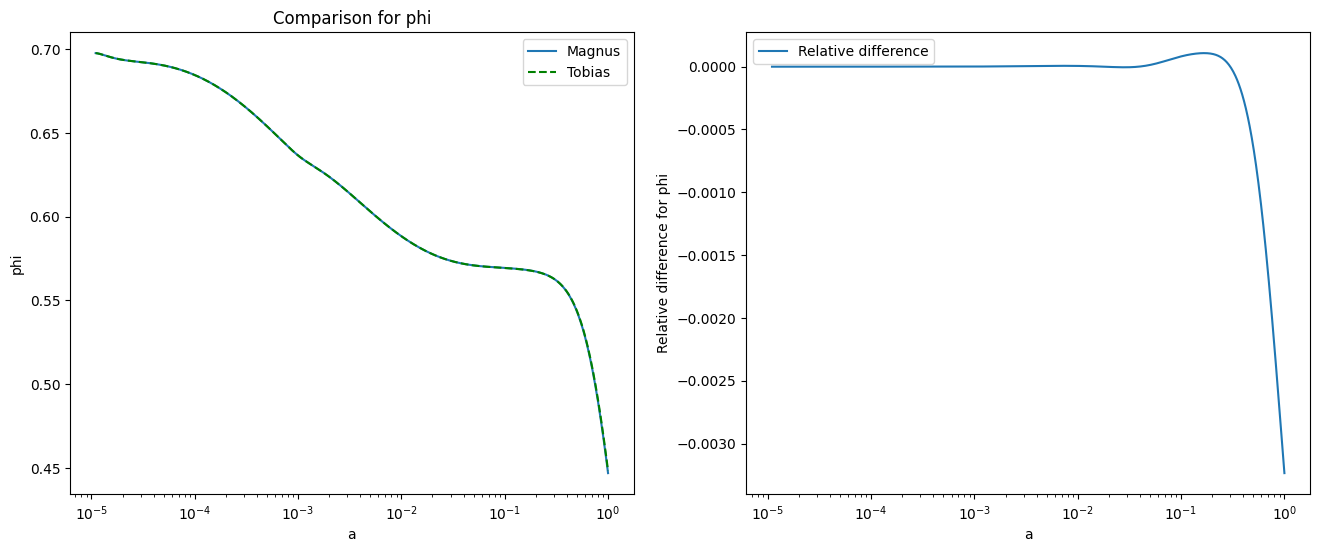

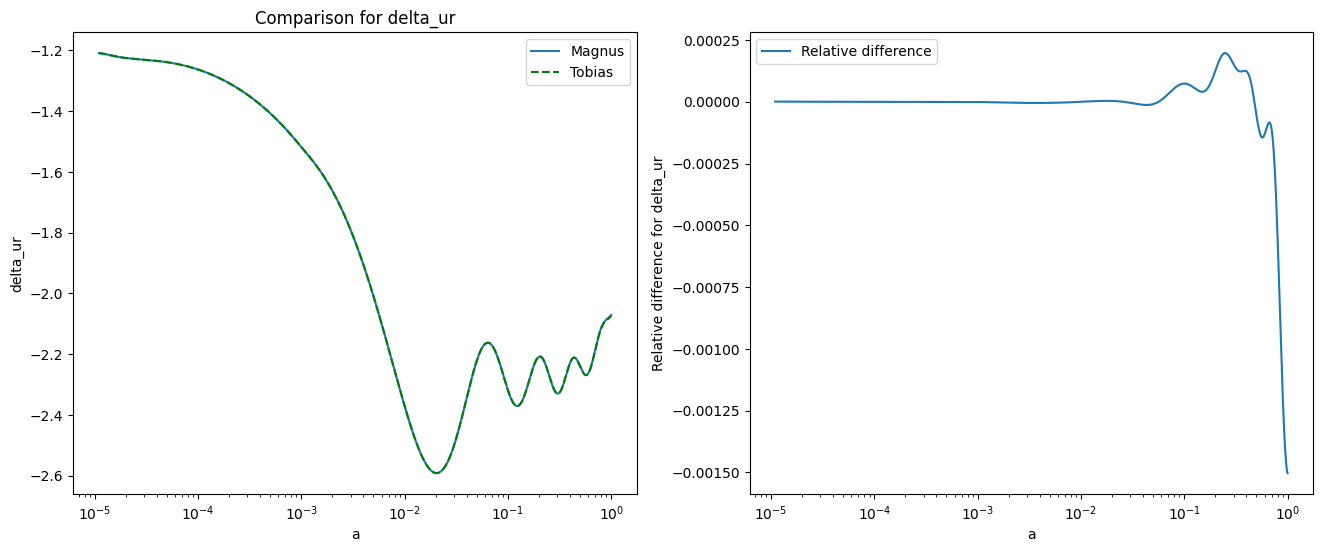

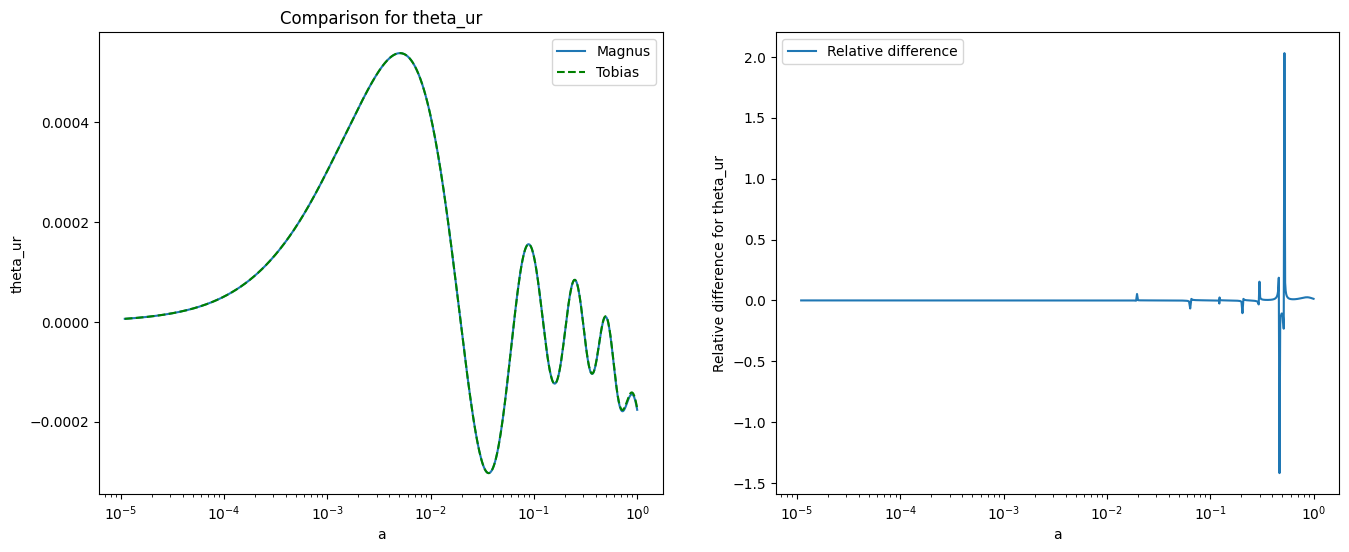

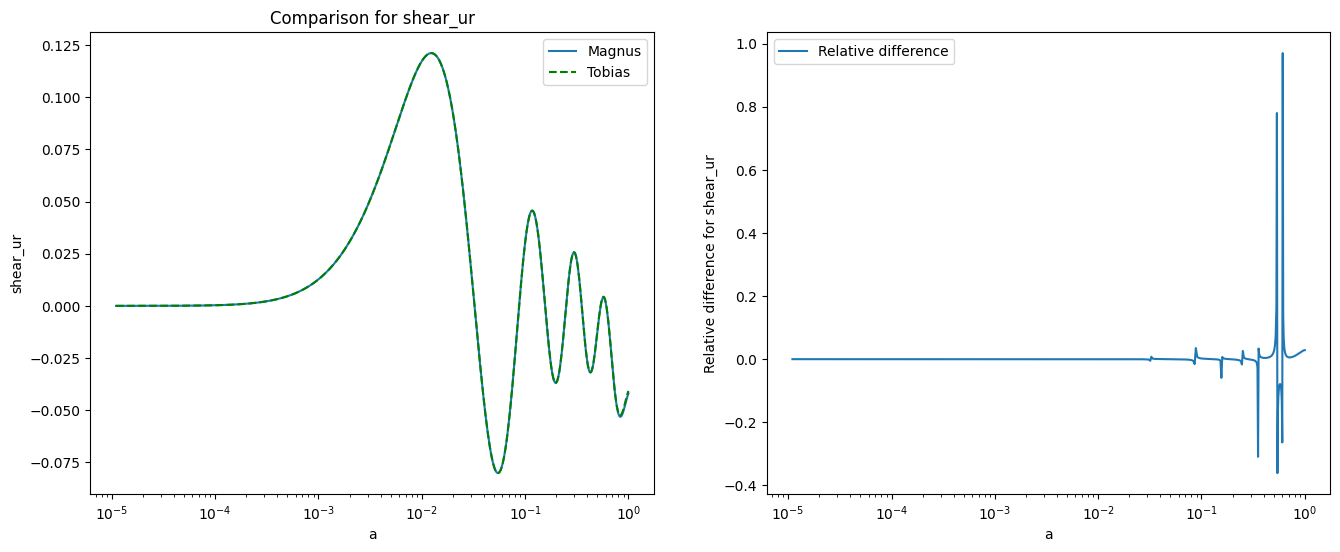

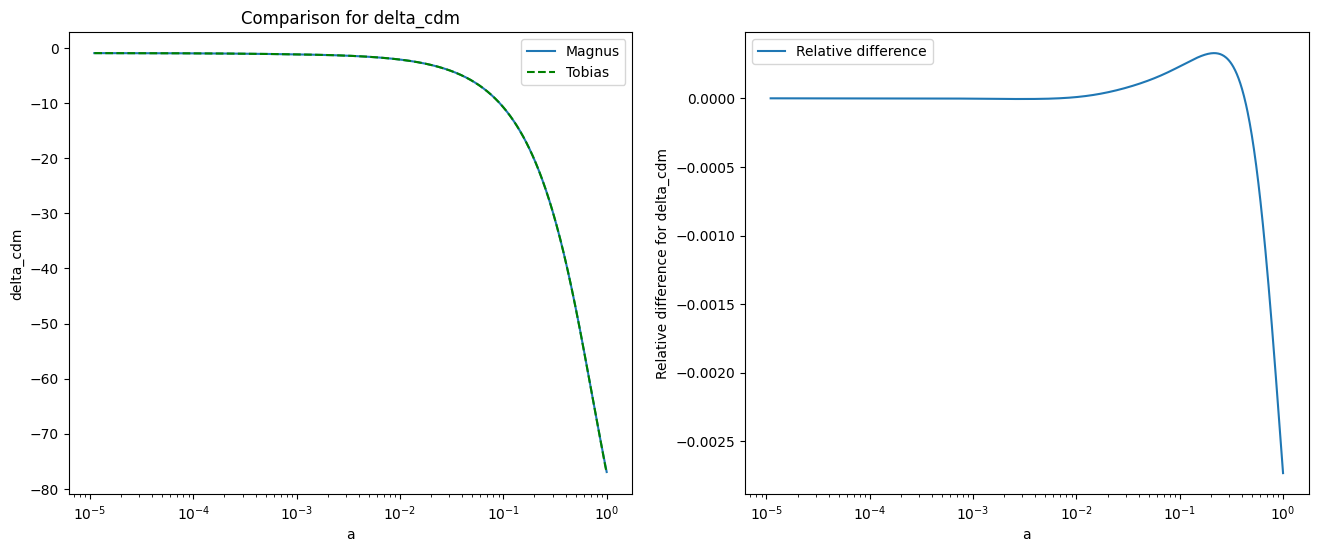

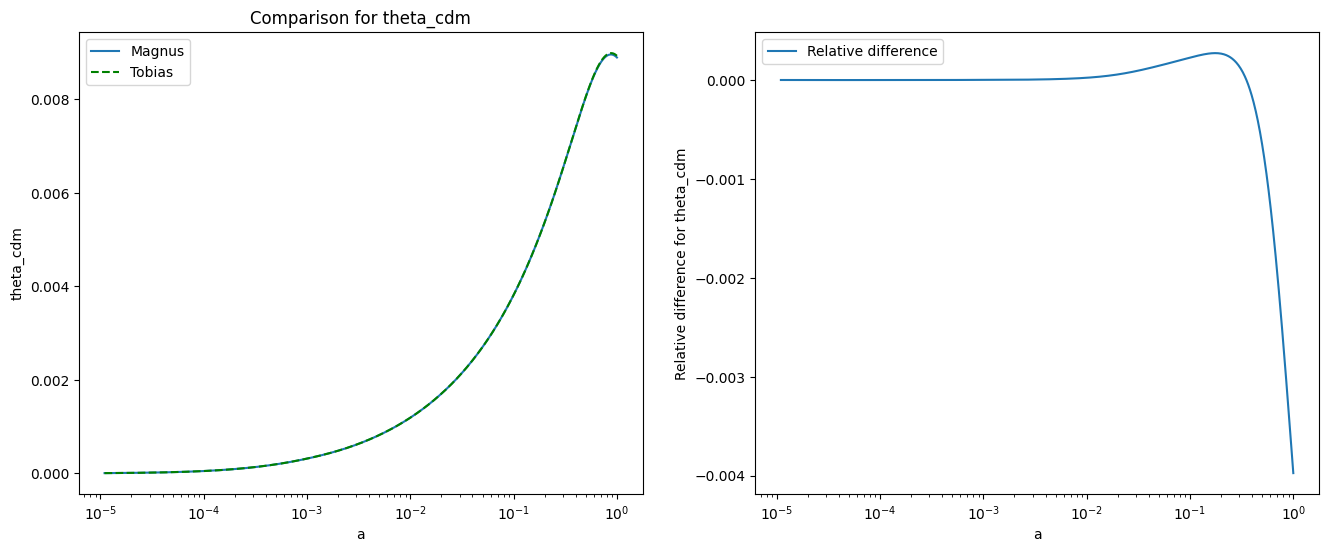

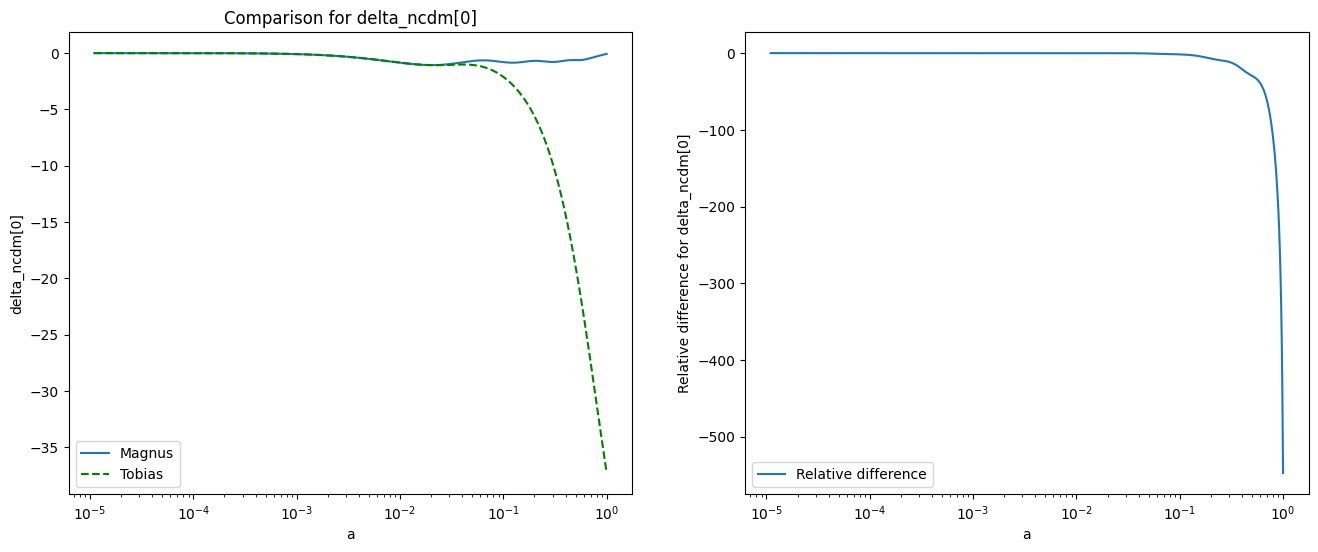

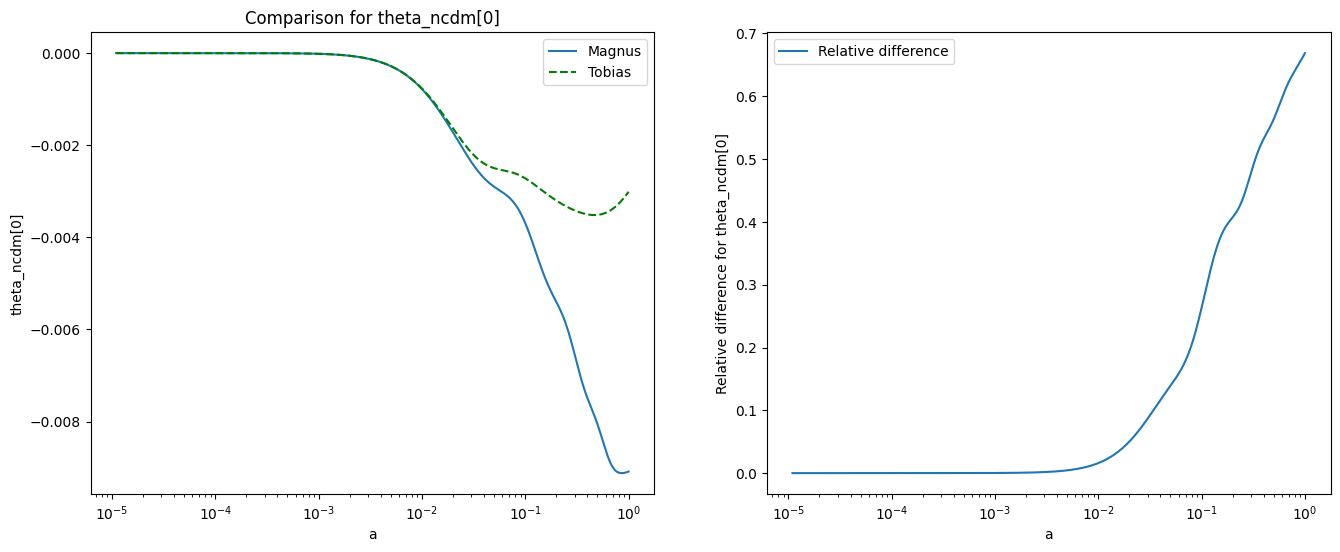

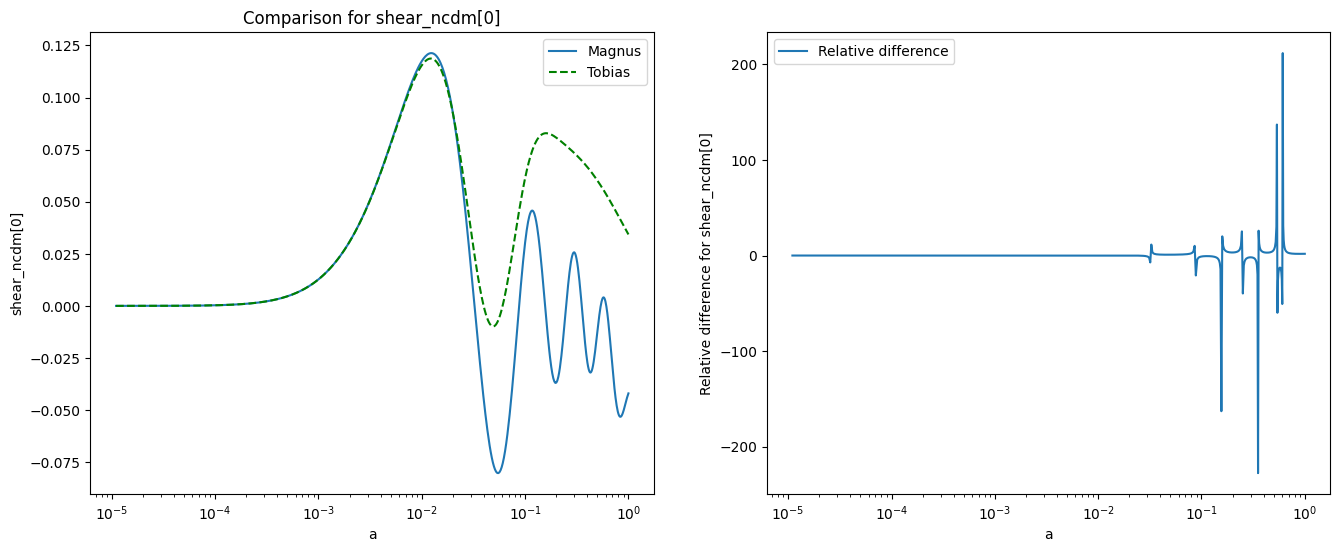

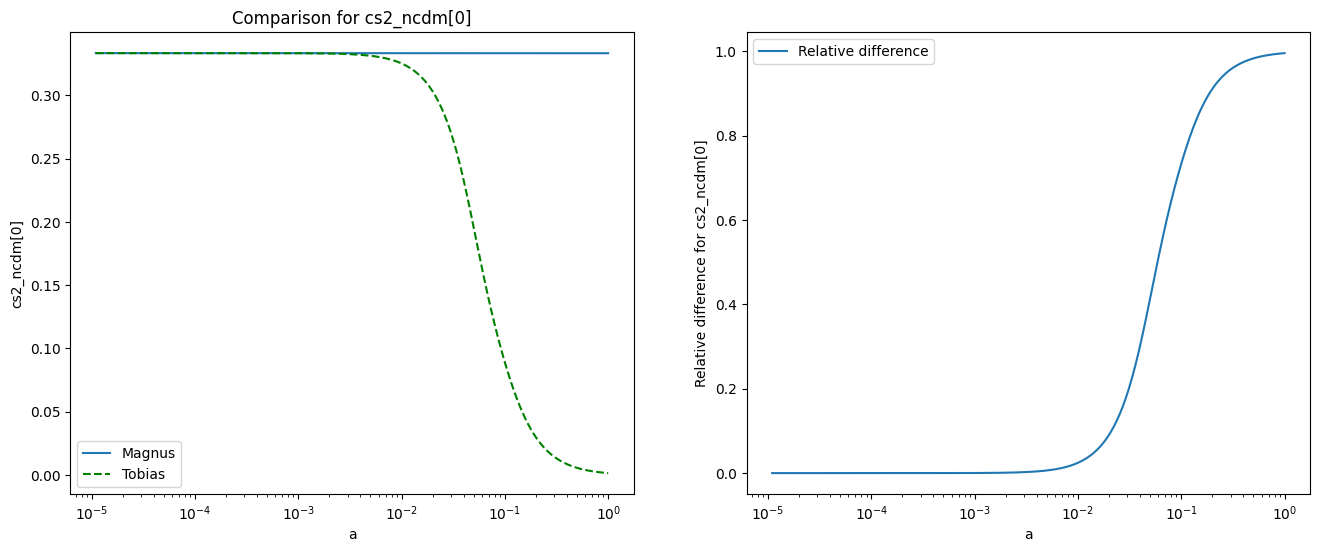

In [7]:
perturbations_Magnus_ncdm = model_Magnus_ncdm.get_perturbations()['scalar'][0]
perturbations_Tobias_ncdm = model_Tobias_ncdm.get_perturbations()['scalar'][0]
perturbations_reference_ncdm = model_reference_ncdm.get_perturbations()['scalar'][0]

a_Magnus = perturbations_Magnus_ncdm['a']
a_reference = perturbations_reference_ncdm['a']
a_Tobias = perturbations_Tobias_ncdm['a']
for key in perturbations_Magnus_ncdm.keys():
    if key == 'a':
        continue
    

    fig, axs = plt.subplots(1,2,figsize=(16,6))
    axs[0].plot(a_Magnus, perturbations_Magnus_ncdm[key], label='Magnus', ls='solid')
    #ax.plot(a_reference, perturbations_reference_ncdm[key], label='Reference', ls='dotted', lw =2, color = 'magenta')
    axs[0].plot(a_Tobias, perturbations_Tobias_ncdm[key], label='Tobias', ls='dashed', color = 'green')
    axs[0].set(xlabel='a', ylabel=key, xscale='log')
    #ax.invert_xaxis()  # Invert x-axis to have z decreasing from left to right
    axs[0].set_title(f'Comparison for {key}')
    axs[0].legend()

    #Create a logscale plot of the relative difference between Magnus and Tobias. First, we need to interpolate the Tobias data to the same a values as Magnus.
    interp_Tobias = interp1d(a_Tobias, perturbations_Tobias_ncdm[key], kind='cubic', fill_value='extrapolate')
    Tobias_interp = interp_Tobias(a_Magnus)

    relative_difference = (perturbations_Magnus_ncdm[key] - Tobias_interp) / perturbations_Magnus_ncdm[key]
    axs[1].plot(a_Magnus, relative_difference, label='Relative difference', ls='solid')
    axs[1].set(xlabel='a', ylabel=f'Relative difference for {key}', xscale='log')
    axs[1].legend()

print(perturbations_Magnus_ncdm.keys())